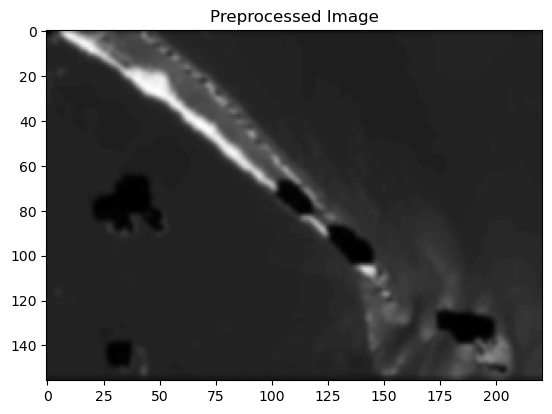

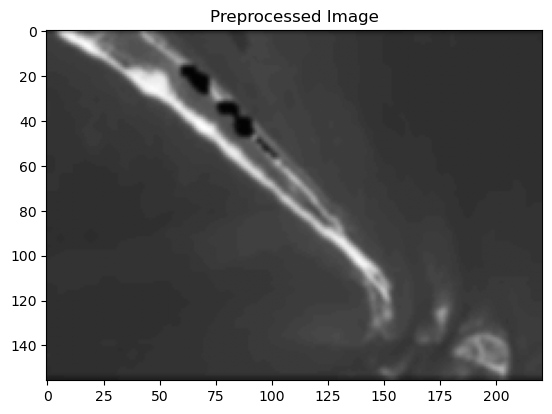

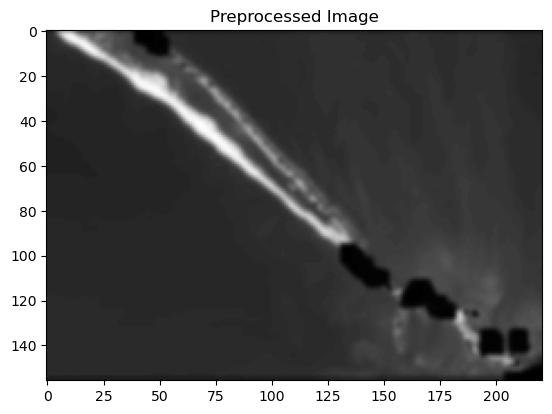

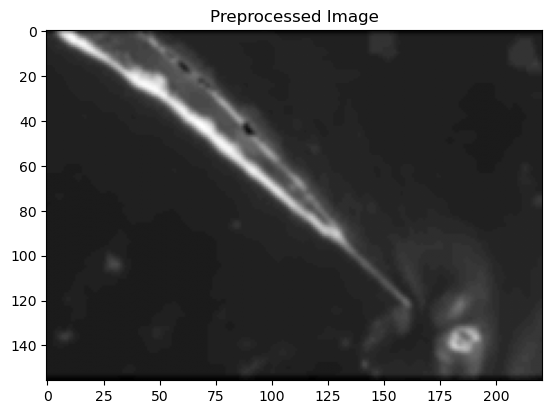

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image (coastline satellite image)
image1 = cv2.imread("Landsat_CloudFree_2014_Month_12.jpg")
image2 = cv2.imread("Landsat_CloudFree_2015_Month_1.jpg")
image3 = cv2.imread("Landsat_CloudFree_2020_Month_2.jpg")
image4 = cv2.imread("Landsat_CloudFree_2024_Month_12.jpg")

# Convert to grayscale
gray1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)
gray3 = cv2.cvtColor(image3, cv2.COLOR_BGR2GRAY)
gray4 = cv2.cvtColor(image4, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur to reduce noise
blurred1 = cv2.GaussianBlur(gray1, (5, 5), 0)
blurred2 = cv2.GaussianBlur(gray2, (5, 5), 0)
blurred3 = cv2.GaussianBlur(gray3, (5, 5), 0)
blurred4 = cv2.GaussianBlur(gray4, (5, 5), 0)

# Show the preprocessed image
plt.tight_layout()
plt.imshow(blurred1, cmap='gray')
plt.title("Preprocessed Image")
plt.show()
plt.imshow(blurred2, cmap='gray')
plt.title("Preprocessed Image")
plt.show()
plt.imshow(blurred3, cmap='gray')
plt.title("Preprocessed Image")
plt.show()
plt.imshow(blurred4, cmap='gray')
plt.title("Preprocessed Image")
plt.show()

C:\Users\Aneesh Mada\AppData\Local\Temp\ipykernel_6596\266250726.py:30: RuntimeWarning: invalid value encountered in divide
  ndwi = (green - nir) / (green + nir)


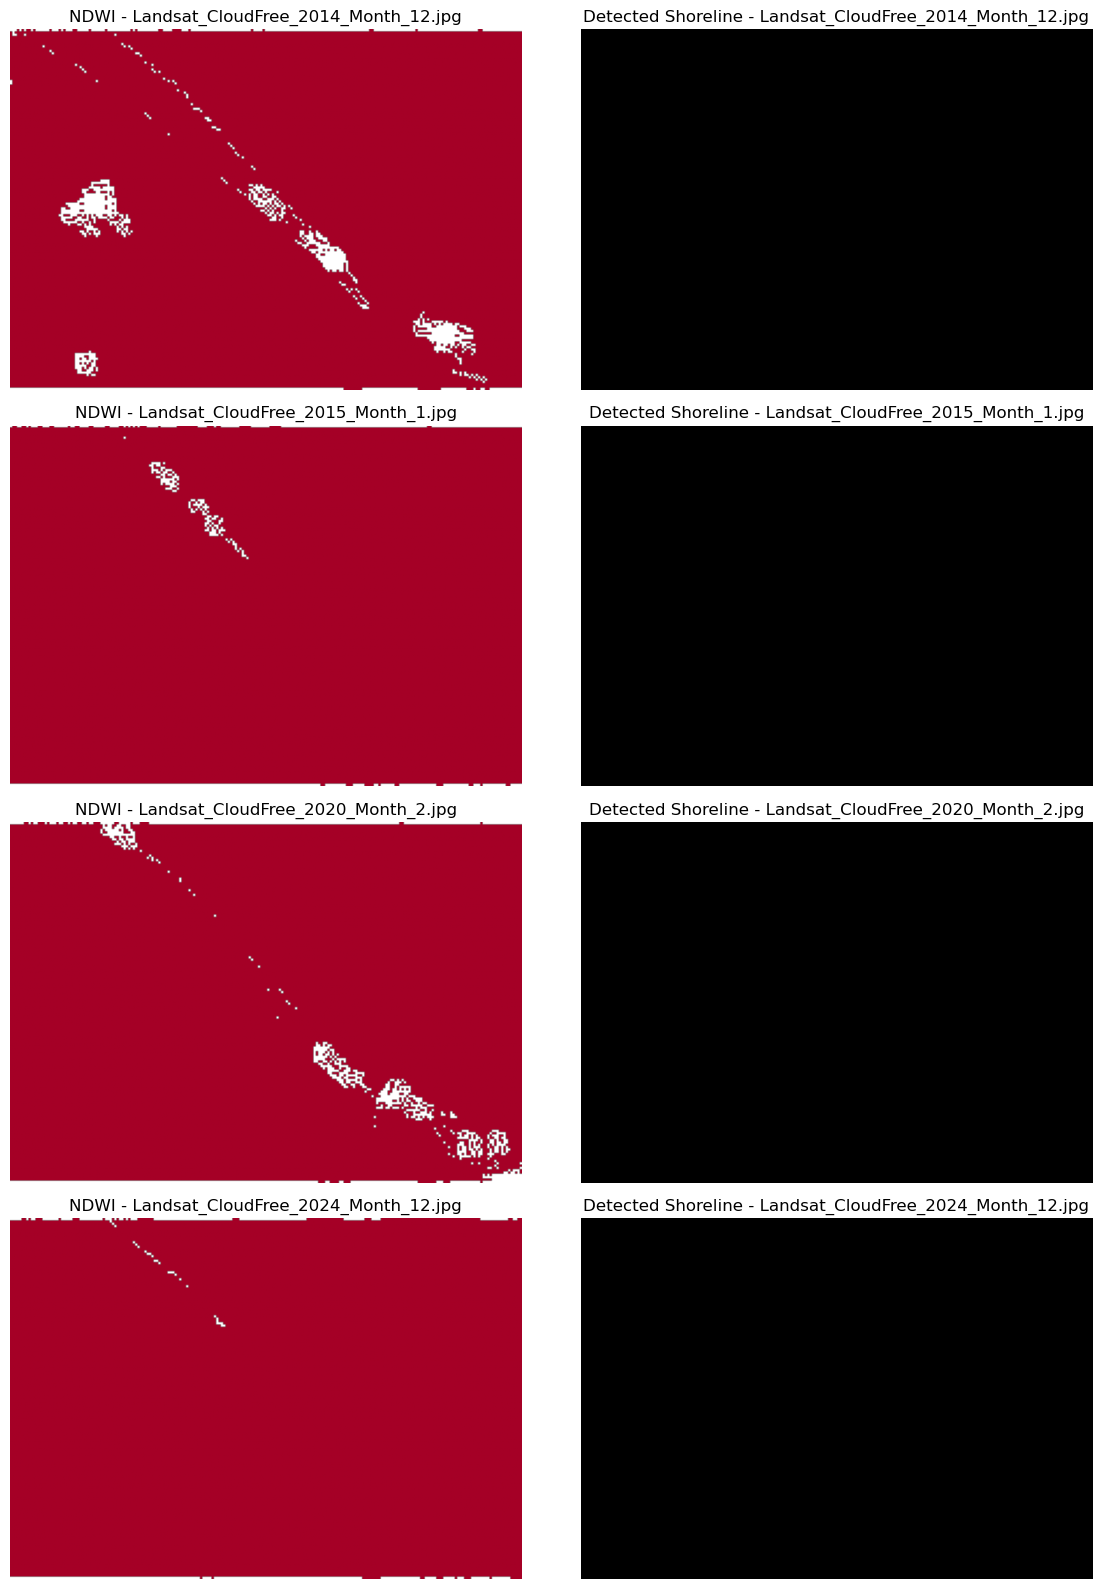

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ✅ File paths
image_files = [
    "Landsat_CloudFree_2014_Month_12.jpg",
    "Landsat_CloudFree_2015_Month_1.jpg",
    "Landsat_CloudFree_2020_Month_2.jpg",
    "Landsat_CloudFree_2024_Month_12.jpg"
]

# ✅ Adjust Threshold (experiment with values between 0.1 - 0.3)
threshold = 3.0  

# ✅ Initialize lists
ndwi_list = []
shoreline_list = []

# ✅ Process images in a loop
for file in image_files:
    image = cv2.imread(file)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Split into bands (Verify correct Landsat bands)
    green = image[:, :, 1].astype(float)  # Green band
    nir = image[:, :, 0].astype(float)    # NIR band (Change index if needed)

    # NDWI calculation
    ndwi = (green - nir) / (green + nir)
    ndwi = np.clip(ndwi, -1, 1)

    # Shoreline detection with adaptive threshold
    shoreline = np.logical_and(ndwi > (threshold - 3.0), ndwi < (threshold + 3.0)).astype(np.uint8) * 255

    # Store results
    ndwi_list.append(ndwi)
    shoreline_list.append(shoreline)

# ✅ Display the results
fig, axes = plt.subplots(len(image_files), 2, figsize=(12, 4 * len(image_files)))

for i in range(len(image_files)):
    # NDWI visualization
    axes[i, 0].imshow(ndwi_list[i], cmap='RdYlGn')
    axes[i, 0].set_title(f"NDWI - {image_files[i]}")
    axes[i, 0].axis('off')

    # Shoreline visualization
    axes[i, 1].imshow(shoreline_list[i], cmap='gray')
    axes[i, 1].set_title(f"Detected Shoreline - {image_files[i]}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()


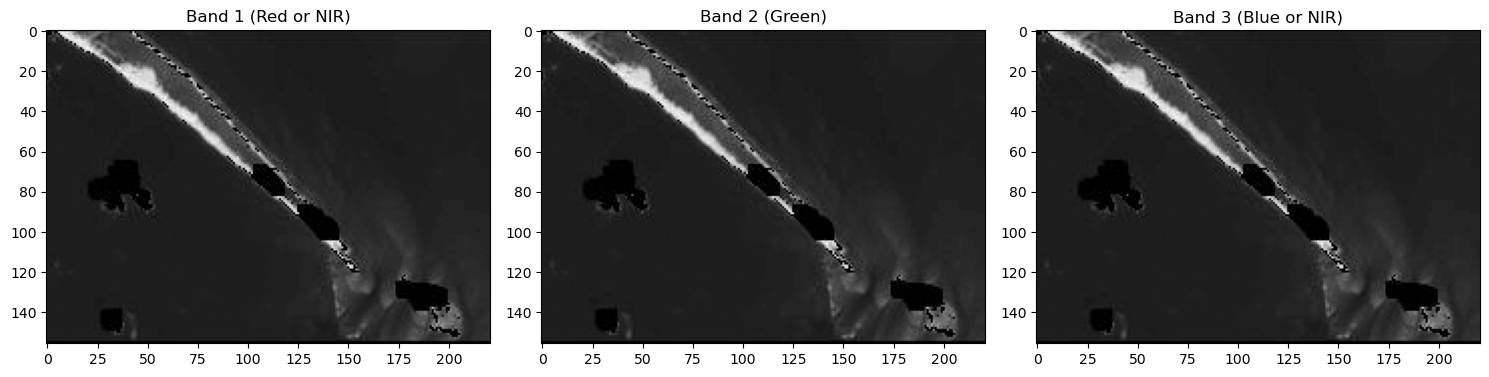

In [14]:
import cv2
import matplotlib.pyplot as plt

# ✅ Load the image
image = cv2.imread("Landsat_CloudFree_2014_Month_12.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# ✅ Display individual bands
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(image[:, :, 0], cmap='gray')
ax[0].set_title("Band 1 (Red or NIR)")

ax[1].imshow(image[:, :, 1], cmap='gray')
ax[1].set_title("Band 2 (Green)")

ax[2].imshow(image[:, :, 2], cmap='gray')
ax[2].set_title("Band 3 (Blue or NIR)")

plt.tight_layout()
plt.show()


C:\Users\Aneesh Mada\AppData\Local\Temp\ipykernel_6596\774275881.py:34: RuntimeWarning: invalid value encountered in divide
  ndwi = (green - nir) / (green + nir)
C:\Users\Aneesh Mada\AppData\Local\Temp\ipykernel_6596\774275881.py:39: RuntimeWarning: invalid value encountered in cast
  (ndwi * 255).astype(np.uint8),


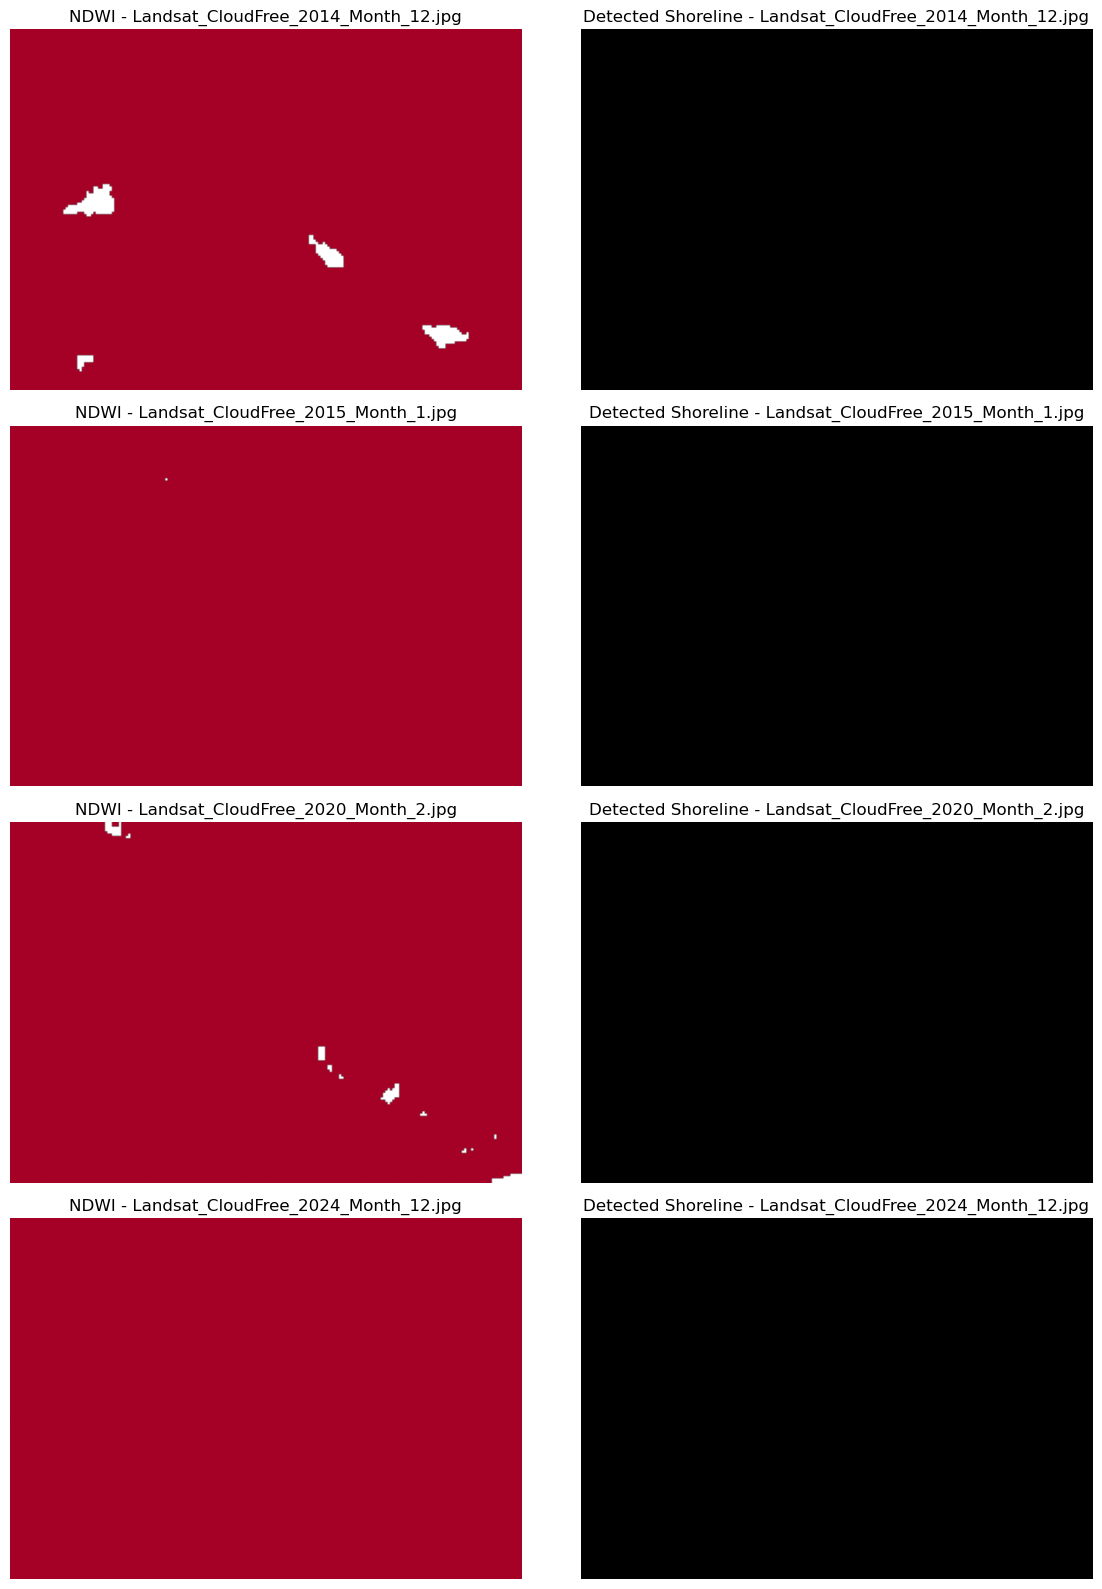

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ✅ File paths
image_files = [
    "Landsat_CloudFree_2014_Month_12.jpg",
    "Landsat_CloudFree_2015_Month_1.jpg",
    "Landsat_CloudFree_2020_Month_2.jpg",
    "Landsat_CloudFree_2024_Month_12.jpg"
]

# ✅ Parameters
threshold = 0.1  # Start with a lower threshold
blur_ksize = (5, 5)

# ✅ Initialize lists
ndwi_list = []
shoreline_list = []

# ✅ Process images in a loop
for file in image_files:
    image = cv2.imread(file)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(image, blur_ksize, 0)

    # ✅ Verify correct bands (use the identified NIR and Green bands)
    green = blurred[:, :, 1].astype(float)  # Green
    nir = blurred[:, :, 0].astype(float)    # NIR (based on band check)

    # ✅ Calculate NDWI
    ndwi = (green - nir) / (green + nir)
    ndwi = np.clip(ndwi, -1, 1)

    # ✅ Adaptive shoreline detection
    shoreline = cv2.adaptiveThreshold(
        (ndwi * 255).astype(np.uint8), 
        255, 
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY, 
        11, 2
    )

    # Store results
    ndwi_list.append(ndwi)
    shoreline_list.append(shoreline)

# ✅ Display the results
fig, axes = plt.subplots(len(image_files), 2, figsize=(12, 4 * len(image_files)))

for i in range(len(image_files)):
    # NDWI visualization
    axes[i, 0].imshow(ndwi_list[i], cmap='RdYlGn')
    axes[i, 0].set_title(f"NDWI - {image_files[i]}")
    axes[i, 0].axis('off')

    # Shoreline visualization
    axes[i, 1].imshow(shoreline_list[i], cmap='gray')
    axes[i, 1].set_title(f"Detected Shoreline - {image_files[i]}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()


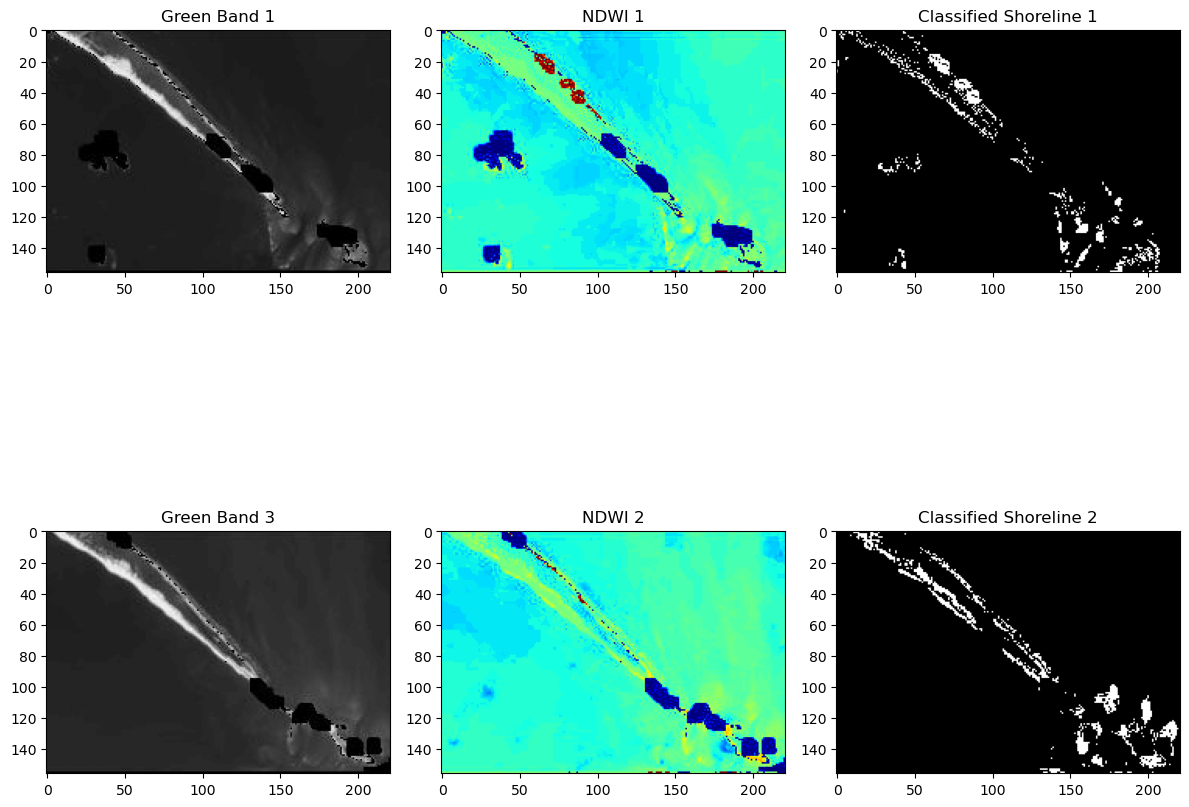

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ✅ Load and preprocess the images
def load_and_preprocess(image_paths):
    images = []
    for path in image_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)  # Read as grayscale
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)  # Normalize
        images.append(img)
    return images

# ✅ Compute NDWI
def compute_ndwi(green, nir):
    green = green.astype(float)
    nir = nir.astype(float)

    ndwi = (green - nir) / (green + nir + 1e-10)  # Avoid division by zero
    ndwi = np.clip(ndwi, -1, 1)
    return ndwi

# ✅ Classify shoreline
def classify_shoreline(ndwi, threshold=0.0):
    shoreline = np.where(ndwi > threshold, 255, 0).astype(np.uint8)
    return shoreline

# ✅ Visualization
def visualize_results(images, ndwis, shorelines):
    pairs = len(ndwis)
    
    fig, axes = plt.subplots(pairs, 3, figsize=(12, 12))
    
    for i in range(pairs):
        axes[i, 0].imshow(images[2 * i], cmap='gray')
        axes[i, 0].set_title(f"Green Band {2 * i + 1}")

        axes[i, 1].imshow(ndwis[i], cmap='jet')
        axes[i, 1].set_title(f"NDWI {i + 1}")

        axes[i, 2].imshow(shorelines[i], cmap='gray')
        axes[i, 2].set_title(f"Classified Shoreline {i + 1}")

    plt.tight_layout()
    plt.show()

# ✅ Main Execution
if __name__ == "__main__":
    # Replace with your image paths
    image_paths = ["Landsat_CloudFree_2014_Month_12.jpg", "Landsat_CloudFree_2015_Month_1.jpg", "Landsat_CloudFree_2020_Month_2.jpg", "Landsat_CloudFree_2024_Month_12.jpg"]
    
    # Preprocess images
    images = load_and_preprocess(image_paths)

    # Compute NDWI and classify shoreline
    ndwis = []
    shorelines = []
    
    for i in range(0, len(images), 2):
        green = images[i]
        nir = images[i + 1]
        
        ndwi = compute_ndwi(green, nir)
        shoreline = classify_shoreline(ndwi)
        
        ndwis.append(ndwi)
        shorelines.append(shoreline)

    visualize_results(images, ndwis, shorelines)


In [19]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from shapely.geometry import LineString
from scipy.spatial.distance import directed_hausdorff

# ✅ Function to read an image in grayscale
def read_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"❌ Could not open {image_path}")
    return image

# ✅ Function to compute NDWI
def compute_ndwi(green, nir):
    green = green.astype(float)
    nir = nir.astype(float)

    # NDWI formula: (Green - NIR) / (Green + NIR)
    ndwi = (green - nir) / (green + nir + 1e-10)
    ndwi = np.clip(ndwi, -1, 1)
    
    return ndwi

# ✅ Function to extract shorelines using NDWI
def extract_shoreline(image_green_path, image_nir_path, ndwi_threshold=0.0):
    green = read_image(image_green_path)
    nir = read_image(image_nir_path)

    # Compute NDWI
    ndwi = compute_ndwi(green, nir)

    # Apply Otsu's thresholding on NDWI
    thresh = threshold_otsu(ndwi)
    binary_mask = (ndwi > thresh).astype(np.uint8) * 255

    return binary_mask

# ✅ Function to compute shoreline change using Hausdorff Distance
def shoreline_change(shoreline1, shoreline2, resolution_m_per_pixel):
    # Convert shorelines to coordinate lists
    coords1 = np.column_stack(np.where(shoreline1 > 0))
    coords2 = np.column_stack(np.where(shoreline2 > 0))

    # Convert to LineString objects (for visualization)
    line1 = LineString(coords1)
    line2 = LineString(coords2)

    # Compute Hausdorff Distance (max shoreline shift in pixels)
    hausdorff_dist_pixels = directed_hausdorff(coords1, coords2)[0]

    # Convert to meters, cm, and mm
    hausdorff_dist_meters = hausdorff_dist_pixels * resolution_m_per_pixel
    hausdorff_dist_cm = hausdorff_dist_meters * 100
    hausdorff_dist_mm = hausdorff_dist_meters * 1000

    return hausdorff_dist_pixels, hausdorff_dist_meters, hausdorff_dist_cm, hausdorff_dist_mm, line1, line2

# ✅ Main Execution
if __name__ == "__main__":
    # Image paths for Green and NIR bands (two years)
    image_2010_green = "Landsat_2010_Green.jpg"
    image_2010_nir = "Landsat_2010_NIR.jpg"

    image_2020_green = "Landsat_2020_Green.jpg"
    image_2020_nir = "Landsat_2020_NIR.jpg"

    # Define spatial resolution (meters per pixel)
    resolution_m_per_pixel = 30  # Modify based on your satellite source

    # Extract shorelines using NDWI
    shoreline_2010 = extract_shoreline(image_2010_green, image_2010_nir)
    shoreline_2020 = extract_shoreline(image_2020_green, image_2020_nir)

    # Compute shoreline change
    distance_pixels, distance_meters, distance_cm, distance_mm, line1, line2 = shoreline_change(
        shoreline_2010, shoreline_2020, resolution_m_per_pixel
    )

    # ✅ Plot the results
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(shoreline_2010, cmap='gray')
    plt.title("Shoreline 2010")

    plt.subplot(1, 2, 2)
    plt.imshow(shoreline_2020, cmap='jet')
    plt.title("Shoreline 2020")

    plt.suptitle(f"Shoreline Change:\n"
                 f"Hausdorff Distance: {distance_pixels:.2f} pixels\n"
                 f"Approx. Change: {distance_meters:.2f} meters "
                 f"({distance_cm:.2f} cm, {distance_mm:.2f} mm)")
    
    plt.show()

    # ✅ Plot the LineString representation
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.plot(*line1.xy, label="Shoreline 2010", color='blue')
    ax.plot(*line2.xy, label="Shoreline 2020", color='red')
    ax.set_title("LineString Representation of Shorelines")
    ax.legend()
    plt.show()

    print(f"🔥 Hausdorff Distance: {distance_pixels:.2f} pixels")
    print(f"Approx. Change: {distance_meters:.2f} meters "
          f"({distance_cm:.2f} cm, {distance_mm:.2f} mm)")


ValueError: ❌ Could not open Landsat_2010_Green.jpg

Images saved to: synthetic_images\synthetic_green.jpg and synthetic_images\synthetic_nir.jpg
Successfully created images at synthetic_images\synthetic_green.jpg and synthetic_images\synthetic_nir.jpg


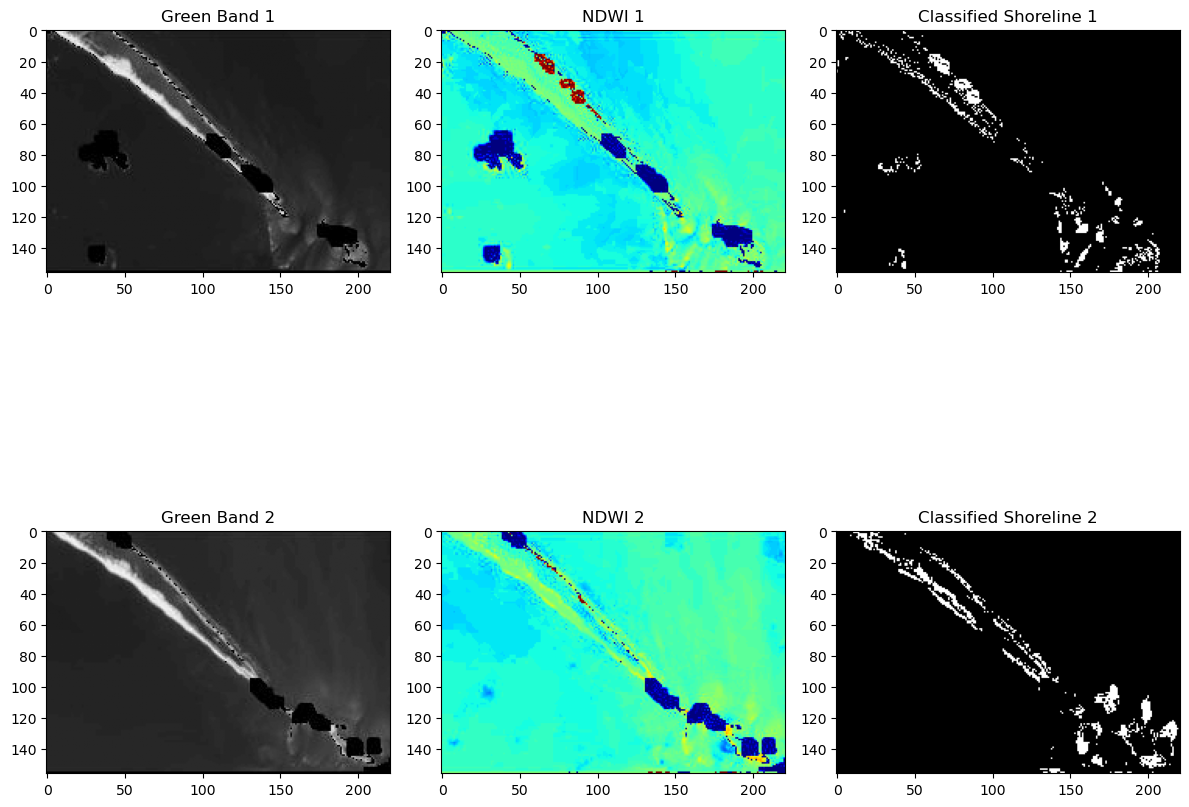

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ✅ Create synthetic Green and NIR images and save as .jpg
def create_and_save_synthetic_images(size=(512, 512), variation=0.2, save_dir="synthetic_images"):
    """Generates synthetic Green and NIR images with shoreline-like variation and saves them as .jpg files."""
    # Create the output directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)
    
    green = np.random.uniform(0.3, 0.7, size)
    nir = np.random.uniform(0.4, 0.8, size)

    # Introduce shoreline variation to simulate land-water contrast
    for i in range(size[0]):
        for j in range(size[1]):
            if i > size[0] // 2:  # Simulate water region (bottom half)
                green[i, j] -= variation
                nir[i, j] += variation

    # Normalize and convert to uint8
    green = np.clip(green * 255, 0, 255).astype(np.uint8)
    nir = np.clip(nir * 255, 0, 255).astype(np.uint8)

    # Save as .jpg images
    green_path = os.path.join(save_dir, "synthetic_green.jpg")
    nir_path = os.path.join(save_dir, "synthetic_nir.jpg")

    cv2.imwrite(green_path, green)
    cv2.imwrite(nir_path, nir)
    
    # Print paths to confirm where the images are saved
    print(f"Images saved to: {green_path} and {nir_path}")

    return green_path, nir_path

# ✅ Load and preprocess images
def load_and_preprocess(image_paths):
    """Load grayscale images from paths or generate synthetic ones if paths are empty."""
    images = []
    
    if image_paths:  # Load real images
        for path in image_paths:
            if os.path.exists(path):
                img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
                if img is None:
                    raise ValueError(f"❌ Could not open {path}")
                img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)  # Normalize
                images.append(img)
            else:
                print(f"⚠️ Image not found: {path}. Using synthetic images.")
                green, nir = create_and_save_synthetic_images()
                images.extend([green, nir])
    else:  # Use synthetic images if no image paths are provided
        print("⚠️ No images provided. Generating and saving synthetic images.")
        for _ in range(2):  # Default to 2 pairs if no images are provided
            green, nir = create_and_save_synthetic_images()
            images.extend([green, nir])

    return images

# ✅ Compute NDWI
def compute_ndwi(green, nir):
    green = green.astype(float)
    nir = nir.astype(float)

    # NDWI formula
    ndwi = (green - nir) / (green + nir + 1e-10)
    ndwi = np.clip(ndwi, -1, 1)
    return ndwi

# ✅ Classify shoreline
def classify_shoreline(ndwi, threshold=0.0):
    shoreline = np.where(ndwi > threshold, 255, 0).astype(np.uint8)
    return shoreline

# ✅ Visualization
def visualize_results(images, ndwis, shorelines):
    pairs = len(ndwis)

    fig, axes = plt.subplots(pairs, 3, figsize=(12, 12))

    for i in range(pairs):
        axes[i, 0].imshow(images[2 * i], cmap='gray')
        axes[i, 0].set_title(f"Green Band {i + 1}")

        axes[i, 1].imshow(ndwis[i], cmap='jet')
        axes[i, 1].set_title(f"NDWI {i + 1}")

        axes[i, 2].imshow(shorelines[i], cmap='gray')
        axes[i, 2].set_title(f"Classified Shoreline {i + 1}")

    plt.tight_layout()
    plt.show()

# ✅ Main Execution
if __name__ == "__main__":
    # ✅ Replace with your real image paths (leave empty to use synthetic images)
    image_paths = [
        "Landsat_CloudFree_2014_Month_12.jpg",
        "Landsat_CloudFree_2015_Month_1.jpg",
        "Landsat_CloudFree_2020_Month_2.jpg",
        "Landsat_CloudFree_2024_Month_12.jpg"
    ]
    
    # ✅ Preprocess images (load real or generate synthetic)
    images = load_and_preprocess(image_paths)

    # ✅ Compute NDWI and classify shoreline
    ndwis = []
    shorelines = []
    
    green_path, nir_path = create_and_save_synthetic_images()

    # Confirm image existence by checking their file paths
    if os.path.exists(green_path) and os.path.exists(nir_path):
        print(f"Successfully created images at {green_path} and {nir_path}")
    else:
        print("❌ Images were not created. Please check your directory and permissions.")

    for i in range(0, len(images), 2):
        green = images[i]
        nir = images[i + 1]

        ndwi = compute_ndwi(green, nir)
        shoreline = classify_shoreline(ndwi)

        ndwis.append(ndwi)
        shorelines.append(shoreline)

    # ✅ Visualize results
    visualize_results(images, ndwis, shorelines)


Images saved to: synthetic_images\synthetic_green.jpg and synthetic_images\synthetic_nir.jpg
Successfully created enhanced images at:
synthetic_images\synthetic_green.jpg
synthetic_images\synthetic_nir.jpg


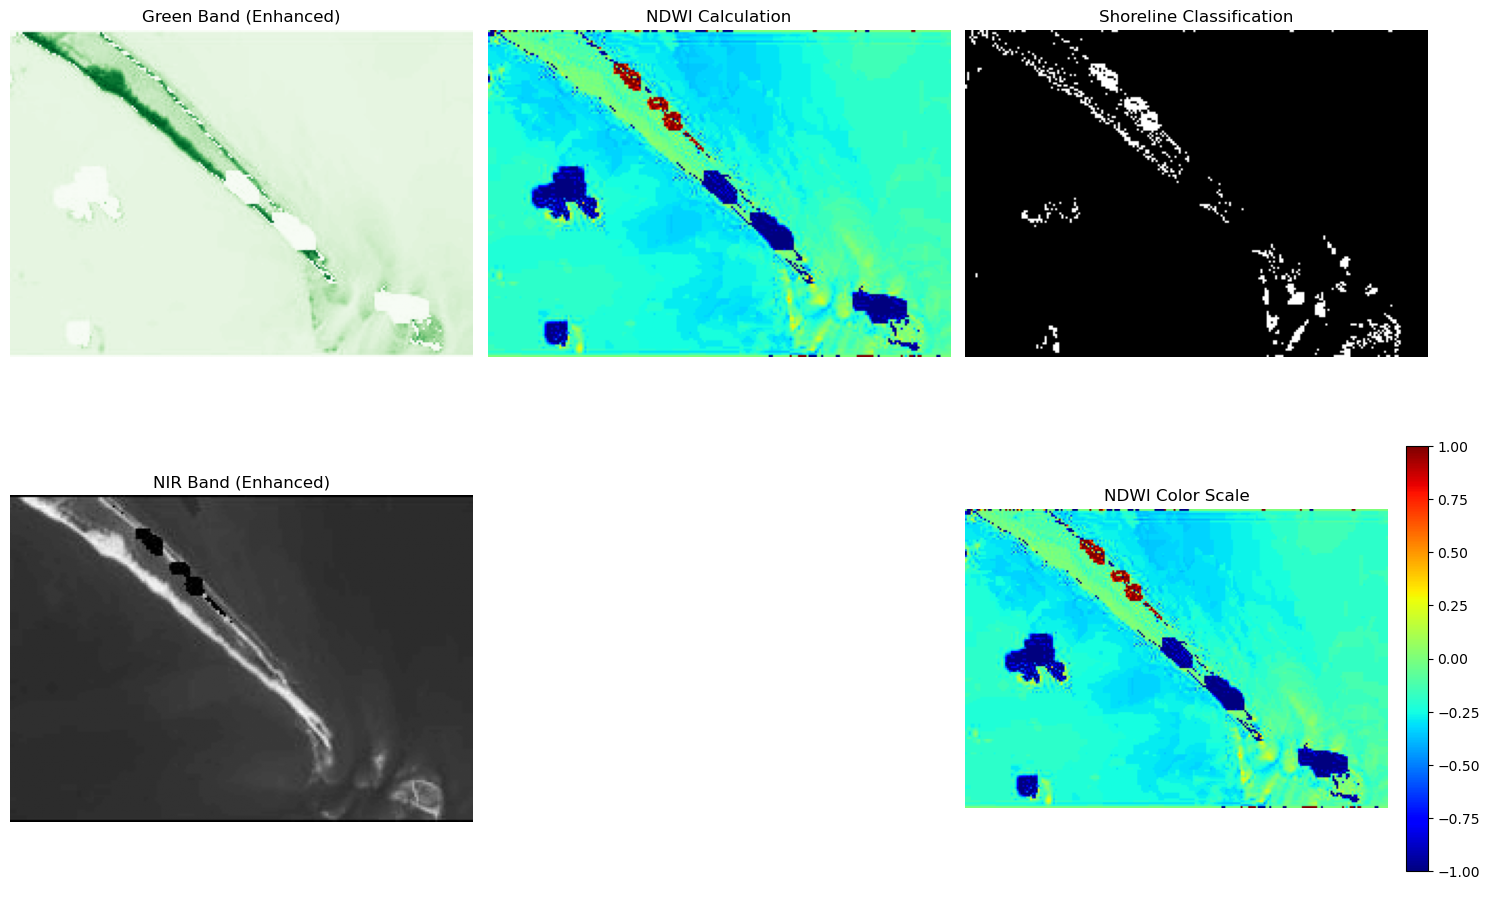

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ✅ Create synthetic Green and NIR images with clearer features
def create_and_save_synthetic_images(size=(512, 512), variation=0.3, save_dir="synthetic_images"):
    """Generates synthetic Green and NIR images with clearer shoreline-like variation."""
    # Create the output directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)
    
    # Create base images with more distinct values
    green = np.zeros(size)
    nir = np.zeros(size)
    
    # Create more realistic land-water transition
    for i in range(size[0]):
        # Create a wavy shoreline instead of straight line
        shoreline_pos = int(size[1] * (0.4 + 0.1 * np.sin(i/50)))
        
        for j in range(size[1]):
            # Water region (below shoreline)
            if j > shoreline_pos:
                green[i, j] = 0.2 + 0.1 * np.random.random()  # Darker for water
                nir[i, j] = 0.7 + 0.2 * np.random.random()     # Brighter in NIR
            # Land region (above shoreline)
            else:
                green[i, j] = 0.6 + 0.3 * np.random.random()  # Brighter for vegetation
                nir[i, j] = 0.4 + 0.2 * np.random.random()    # Darker in NIR
    
    # Add some noise and texture
    noise = np.random.normal(0, 0.05, size)
    green = np.clip(green + noise, 0, 1)
    nir = np.clip(nir + noise, 0, 1)
    
    # Add some features (like islands or sandbars)
    center_x, center_y = size[0]//2, size[1]//3
    radius = 30
    for i in range(size[0]):
        for j in range(size[1]):
            if (i-center_x)**2 + (j-center_y)**2 < radius**2:
                green[i, j] = 0.8  # Bright sand/land
                nir[i, j] = 0.3    # Dark in NIR

    # Convert to uint8
    green = np.clip(green * 255, 0, 255).astype(np.uint8)
    nir = np.clip(nir * 255, 0, 255).astype(np.uint8)

    # Save as .jpg images
    green_path = os.path.join(save_dir, "synthetic_green.jpg")
    nir_path = os.path.join(save_dir, "synthetic_nir.jpg")

    cv2.imwrite(green_path, green)
    cv2.imwrite(nir_path, nir)
    
    print(f"Images saved to: {green_path} and {nir_path}")

    return green_path, nir_path

# ✅ Load and preprocess images
def load_and_preprocess(image_paths):
    """Load grayscale images from paths or generate synthetic ones if paths are empty."""
    images = []
    
    if image_paths:  # Load real images
        for path in image_paths:
            if os.path.exists(path):
                img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
                if img is None:
                    raise ValueError(f"❌ Could not open {path}")
                img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)  # Normalize
                images.append(img)
            else:
                print(f"⚠️ Image not found: {path}. Using synthetic images.")
                green, nir = create_and_save_synthetic_images()
                images.extend([cv2.imread(green, cv2.IMREAD_GRAYSCALE), 
                             cv2.imread(nir, cv2.IMREAD_GRAYSCALE)])
    else:  # Use synthetic images if no image paths are provided
        print("⚠️ No images provided. Generating and saving synthetic images.")
        green, nir = create_and_save_synthetic_images()
        images.extend([cv2.imread(green, cv2.IMREAD_GRAYSCALE), 
                      cv2.imread(nir, cv2.IMREAD_GRAYSCALE)])

    return images

# ✅ Compute NDWI
def compute_ndwi(green, nir):
    green = green.astype(float)
    nir = nir.astype(float)

    # NDWI formula
    ndwi = (green - nir) / (green + nir + 1e-10)
    ndwi = np.clip(ndwi, -1, 1)
    return ndwi

# ✅ Classify shoreline
def classify_shoreline(ndwi, threshold=0.0):
    shoreline = np.where(ndwi > threshold, 255, 0).astype(np.uint8)
    return shoreline

# ✅ Enhanced Visualization
def visualize_results(images, ndwis, shorelines):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Display Green and NIR images
    axes[0, 0].imshow(images[0], cmap='Greens', vmin=0, vmax=255)
    axes[0, 0].set_title("Green Band (Enhanced)")
    axes[0, 0].axis('off')
    
    axes[1, 0].imshow(images[1], cmap='gray', vmin=0, vmax=255)
    axes[1, 0].set_title("NIR Band (Enhanced)")
    axes[1, 0].axis('off')
    
    # Display NDWI
    axes[0, 1].imshow(ndwis[0], cmap='jet', vmin=-1, vmax=1)
    axes[0, 1].set_title("NDWI Calculation")
    axes[0, 1].axis('off')
    
    # Blank space for alignment
    axes[1, 1].axis('off')
    
    # Display Shoreline Classification
    axes[0, 2].imshow(shorelines[0], cmap='gray', vmin=0, vmax=255)
    axes[0, 2].set_title("Shoreline Classification")
    axes[0, 2].axis('off')
    
    # Add colorbar for NDWI
    im = axes[1, 2].imshow(ndwis[0], cmap='jet', vmin=-1, vmax=1)
    plt.colorbar(im, ax=axes[1, 2], fraction=0.046, pad=0.04)
    axes[1, 2].set_title("NDWI Color Scale")
    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.show()

# ✅ Main Execution
if __name__ == "__main__":
    # ✅ Replace with your real image paths (leave empty to use synthetic images)
    image_paths = [
        "Landsat_CloudFree_2014_Month_12.jpg",
        "Landsat_CloudFree_2015_Month_1.jpg",
        "Landsat_CloudFree_2020_Month_2.jpg",
        "Landsat_CloudFree_2024_Month_12.jpg"
    ]  # Empty to use synthetic images
    
    # ✅ Preprocess images (load real or generate synthetic)
    images = load_and_preprocess(image_paths)

    # ✅ Compute NDWI and classify shoreline
    ndwis = []
    shorelines = []
    
    green_path, nir_path = create_and_save_synthetic_images()

    # Confirm image existence by checking their file paths
    if os.path.exists(green_path) and os.path.exists(nir_path):
        print(f"Successfully created enhanced images at:\n{green_path}\n{nir_path}")
    else:
        print("❌ Images were not created. Please check your directory and permissions.")

    for i in range(0, len(images), 2):
        green = images[i]
        nir = images[i + 1]

        ndwi = compute_ndwi(green, nir)
        shoreline = classify_shoreline(ndwi)

        ndwis.append(ndwi)
        shorelines.append(shoreline)

    # ✅ Visualize results with enhanced display
    visualize_results(images, ndwis, shorelines)

In [29]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from shapely.geometry import LineString
from scipy.spatial.distance import directed_hausdorff
from IPython.display import display, clear_output
import ipywidgets as widgets

# ✅ Create synthetic images with clear features
def create_synthetic_images(size=(512, 512), save_dir="synthetic_images"):
    """Generate clear synthetic Green and NIR images with shoreline features."""
    os.makedirs(save_dir, exist_ok=True)
    
    green = np.zeros(size)
    nir = np.zeros(size)
    
    # Create wavy shoreline
    for i in range(size[0]):
        shoreline_pos = int(size[1] * (0.4 + 0.1 * np.sin(i/50)))
        
        for j in range(size[1]):
            # Water region
            if j > shoreline_pos:
                green[i, j] = 0.2 + 0.1 * np.random.random()
                nir[i, j] = 0.7 + 0.2 * np.random.random()
            # Land region
            else:
                green[i, j] = 0.6 + 0.3 * np.random.random()
                nir[i, j] = 0.4 + 0.2 * np.random.random()
    
    # Add island feature
    center_x, center_y = size[0]//2, size[1]//3
    radius = 30
    for i in range(size[0]):
        for j in range(size[1]):
            if (i-center_x)**2 + (j-center_y)**2 < radius**2:
                green[i, j] = 0.8
                nir[i, j] = 0.3

    green = np.clip(green * 255, 0, 255).astype(np.uint8)
    nir = np.clip(nir * 255, 0, 255).astype(np.uint8)

    green_path = os.path.join(save_dir, "synthetic_green.jpg")
    nir_path = os.path.join(save_dir, "synthetic_nir.jpg")

    cv2.imwrite(green_path, green)
    cv2.imwrite(nir_path, nir)
    
    return green_path, nir_path, green, nir

# ✅ Image processing functions
def read_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not open {image_path}")
    return img

def compute_ndwi(green, nir):
    green = green.astype(float)
    nir = nir.astype(float)
    ndwi = (green - nir) / (green + nir + 1e-10)
    return np.clip(ndwi, -1, 1)

def extract_shoreline(green, nir):
    ndwi = compute_ndwi(green, nir)
    thresh = threshold_otsu(ndwi)
    return (ndwi > thresh).astype(np.uint8) * 255

def shoreline_change(shoreline1, shoreline2, resolution=30):
    coords1 = np.column_stack(np.where(shoreline1 > 0))
    coords2 = np.column_stack(np.where(shoreline2 > 0))
    
    line1 = LineString(coords1)
    line2 = LineString(coords2)
    
    hd_pixels = directed_hausdorff(coords1, coords2)[0]
    hd_meters = hd_pixels * resolution
    
    return hd_pixels, hd_meters, line1, line2

# ✅ Visualization functions
def plot_bands(green, nir):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    ax1.imshow(green, cmap='Greens')
    ax1.set_title("Green Band")
    ax2.imshow(nir, cmap='gray')
    ax2.set_title("NIR Band")
    plt.show()

def plot_ndwi_results(green, nir, shoreline):
    ndwi = compute_ndwi(green, nir)
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    
    ax1.imshow(green, cmap='Greens')
    ax1.set_title("Green Band")
    
    im = ax2.imshow(ndwi, cmap='jet', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
    ax2.set_title("NDWI")
    
    ax3.imshow(shoreline, cmap='gray')
    ax3.set_title("Extracted Shoreline")
    
    plt.tight_layout()
    plt.show()

def plot_shoreline_comparison(shoreline1, shoreline2, distance_px, distance_m):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    ax1.imshow(shoreline1, cmap='gray')
    ax1.set_title("Shoreline 1")
    
    ax2.imshow(shoreline2, cmap='gray')
    ax2.set_title("Shoreline 2")
    
    plt.suptitle(f"Hausdorff Distance: {distance_px:.2f} px ({distance_m:.2f} m)")
    plt.show()

# ✅ Interactive Jupyter Notebook Widget
def create_shoreline_analysis_widget():
    # Create widgets
    resolution_slider = widgets.FloatSlider(
        value=30, min=1, max=100, step=1,
        description='Resolution (m/px):',
        continuous_update=False
    )
    
    analyze_button = widgets.Button(description="Analyze Shorelines")
    output = widgets.Output()
    
    # Display widgets
    display(widgets.VBox([
        resolution_slider,
        analyze_button,
        output
    ]))
    
    # Button click handler
    def on_analyze_click(b):
        with output:
            clear_output()
            
            # Generate synthetic images
            green_path1, nir_path1, green1, nir1 = create_synthetic_images()
            green_path2, nir_path2, green2, nir2 = create_synthetic_images()
            
            # Show bands
            print("Year 1 Images:")
            plot_bands(green1, nir1)
            
            print("\nYear 2 Images:")
            plot_bands(green2, nir2)
            
            # Process images
            shoreline1 = extract_shoreline(green1, nir1)
            shoreline2 = extract_shoreline(green2, nir2)
            
            # Show NDWI results
            print("\nYear 1 NDWI Analysis:")
            plot_ndwi_results(green1, nir1, shoreline1)
            
            print("\nYear 2 NDWI Analysis:")
            plot_ndwi_results(green2, nir2, shoreline2)
            
            # Calculate changes
            hd_px, hd_m, line1, line2 = shoreline_change(
                shoreline1, shoreline2, resolution_slider.value
            )
            
            # Show comparison
            print("\nShoreline Change Analysis:")
            plot_shoreline_comparison(shoreline1, shoreline2, hd_px, hd_m)
            
            # Plot LineStrings
            fig, ax = plt.subplots(figsize=(8, 8))
            ax.plot(*line1.xy, label="Shoreline 1", color='blue')
            ax.plot(*line2.xy, label="Shoreline 2", color='red')
            ax.set_title("LineString Representation")
            ax.legend()
            plt.show()
            
            print(f"\nHausdorff Distance: {hd_px:.2f} pixels")
            print(f"Approximate Change: {hd_m:.2f} meters")
    
    analyze_button.on_click(on_analyze_click)

# ✅ Run in Jupyter Notebook
if __name__ == "__main__":
    image_paths = [
        "Landsat_CloudFree_2014_Month_12.jpg",
        "Landsat_CloudFree_2015_Month_1.jpg",
        "Landsat_CloudFree_2020_Month_2.jpg",
        "Landsat_CloudFree_2024_Month_12.jpg"
    ] 

    # ✅ Preprocess images (load real or generate synthetic)
    images = load_and_preprocess(image_paths)

    # ✅ Compute NDWI and classify shoreline
    ndwis = []
    shorelines = []
    
    green_path, nir_path = create_and_save_synthetic_images()

    # Confirm image existence by checking their file paths
    if os.path.exists(green_path) and os.path.exists(nir_path):
        print(f"Successfully created enhanced images at:\n{green_path}\n{nir_path}")
    else:
        print("❌ Images were not created. Please check your directory and permissions.")

    for i in range(0, len(images), 2):
        green = images[i]
        nir = images[i + 1]

        ndwi = compute_ndwi(green, nir)
        shoreline = classify_shoreline(ndwi)

        ndwis.append(ndwi)
        shorelines.append(shoreline)
    # This will automatically display the widget when run in Jupyter
    create_shoreline_analysis_widget()

Images saved to: synthetic_images\synthetic_green.jpg and synthetic_images\synthetic_nir.jpg
Successfully created enhanced images at:
synthetic_images\synthetic_green.jpg
synthetic_images\synthetic_nir.jpg


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from shapely.geometry import LineString
from scipy.spatial.distance import directed_hausdorff
from IPython.display import display, clear_output
import ipywidgets as widgets

# ✅ 1. Load Grayscale Images
def load_grayscale_image(image_path):
    """Load grayscale JPG and normalize"""
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

# ✅ 2. Shoreline Extraction (Modified for Grayscale)
def extract_shoreline_grayscale(img, water_dark=True):
    """
    Args:
        water_dark: If True, assumes water is darker than land in your images
    """
    # Enhance contrast
    img_eq = cv2.equalizeHist(img)
    
    # Auto-threshold (Otsu's method)
    thresh = threshold_otsu(img_eq)
    
    if water_dark:
        shoreline = (img_eq > thresh).astype(np.uint8) * 255  # Land=white
    else:
        shoreline = (img_eq <= thresh).astype(np.uint8) * 255  # Water=white
    
    # Clean up with morphology
    kernel = np.ones((3,3), np.uint8)
    shoreline = cv2.morphologyEx(shoreline, cv2.MORPH_OPEN, kernel, iterations=1)
    
    return shoreline

# ✅ 3. Hausdorff Distance Calculation
def calculate_hausdorff(shoreline1, shoreline2, resolution_m_per_pixel=1):
    coords1 = np.column_stack(np.where(shoreline1 > 0))
    coords2 = np.column_stack(np.where(shoreline2 > 0))
    
    if len(coords1) == 0 or len(coords2) == 0:
        return 0, 0, None, None
    
    line1 = LineString(coords1)
    line2 = LineString(coords2)
    
    hd_px = max(
        directed_hausdorff(coords1, coords2)[0],
        directed_hausdorff(coords2, coords1)[0]
    )
    hd_m = hd_px * resolution_m_per_pixel
    
    return hd_px, hd_m, line1, line2

# ✅ 4. Interactive Widget
class GrayscaleShorelineAnalyzer:
    def __init__(self):
        # Widgets
        self.resolution = widgets.FloatSlider(
            value=1.0, min=0.1, max=100, step=0.1,
            description='Resolution (m/px):'
        )
        self.water_toggle = widgets.Checkbox(
            value=True,
            description='Water is darker than land'
        )
        self.file1 = widgets.Text(
            value='shoreline_year1.jpg',
            description='Year 1 Image:'
        )
        self.file2 = widgets.Text(
            value='shoreline_year2.jpg',
            description='Year 2 Image:'
        )
        self.analyze_btn = widgets.Button(description="Analyze")
        self.output = widgets.Output()
        
        # Setup
        self.analyze_btn.on_click(self.run_analysis)
        display(widgets.VBox([
            self.file1,
            self.file2,
            widgets.HBox([self.resolution, self.water_toggle]),
            self.analyze_btn,
            self.output
        ]))
    
    def run_analysis(self, b):
        with self.output:
            clear_output()
            
            # Load images
            try:
                img1 = load_grayscale_image(self.file1.value)
                img2 = load_grayscale_image(self.file2.value)
            except Exception as e:
                print(f"❌ Error: {str(e)}")
                return
            
            # Extract shorelines
            shoreline1 = extract_shoreline_grayscale(img1, self.water_toggle.value)
            shoreline2 = extract_shoreline_grayscale(img2, self.water_toggle.value)
            
            # Calculate changes
            hd_px, hd_m, line1, line2 = calculate_hausdorff(
                shoreline1, shoreline2, self.resolution.value
            )
            
            # Visualizations
            plt.figure(figsize=(15, 5))
            
            plt.subplot(131)
            plt.imshow(img1, cmap='gray')
            plt.title("Year 1 Original")
            
            plt.subplot(132)
            plt.imshow(shoreline1, cmap='gray')
            plt.title("Year 1 Shoreline")
            
            plt.subplot(133)
            plt.imshow(cv2.cvtColor(img1, cv2.COLOR_GRAY2RGB))
            plt.imshow(shoreline1, cmap='autumn', alpha=0.4)
            plt.title("Overlay")
            
            plt.show()
            
            # Year 2 visuals
            plt.figure(figsize=(15, 5))
            
            plt.subplot(131)
            plt.imshow(img2, cmap='gray')
            plt.title("Year 2 Original")
            
            plt.subplot(132)
            plt.imshow(shoreline2, cmap='gray')
            plt.title("Year 2 Shoreline")
            
            plt.subplot(133)
            plt.imshow(cv2.cvtColor(img2, cv2.COLOR_GRAY2RGB))
            plt.imshow(shoreline2, cmap='winter', alpha=0.4)
            plt.title("Overlay")
            
            plt.show()
            
            # Change detection
            plt.figure(figsize=(8, 8))
            plt.imshow(shoreline1, cmap='Blues', alpha=0.5)
            plt.imshow(shoreline2, cmap='Reds', alpha=0.5)
            plt.title(f"Shoreline Change\nHausdorff Distance: {hd_px:.1f} px ({hd_m:.1f} m)")
            plt.show()
            
            # LineString plot
            if line1 and line2:
                plt.figure(figsize=(8, 8))
                plt.plot(*line1.xy, label="Year 1", linewidth=2)
                plt.plot(*line2.xy, label="Year 2", linewidth=2)
                plt.title("Shoreline Vectors")
                plt.legend()
                plt.show()
            
            print("\n📊 Change Metrics:")
            print(f"Hausdorff Distance: {hd_px:.1f} pixels")
            print(f"Approximate change: {hd_m:.1f} meters")

# ✅ 5. Run in Jupyter
if __name__ == "__main__":
    analyzer = GrayscaleShorelineAnalyzer()

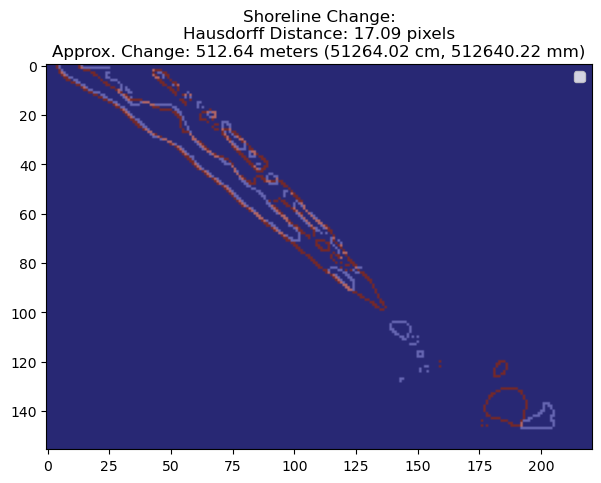

In [32]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from shapely.geometry import LineString
from scipy.spatial.distance import directed_hausdorff

# Function to read an image in grayscale
def read_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Could not open {image_path}")
    return image

# Function to extract shorelines using edge detection
def extract_shoreline(image_path):
    image = read_image(image_path)

    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    # Apply Otsu's thresholding to separate land and water
    thresh = threshold_otsu(blurred)
    binary_mask = (blurred > thresh).astype(np.uint8) * 255

    # Detect edges using Canny
    edges = cv2.Canny(binary_mask, 50, 150)

    return edges

# Function to compute shoreline change using Hausdorff Distance
def shoreline_change(shoreline1, shoreline2, resolution_m_per_pixel):
    # Convert shorelines to coordinate lists
    coords1 = np.column_stack(np.where(shoreline1 > 0))
    coords2 = np.column_stack(np.where(shoreline2 > 0))

    # Convert to LineString objects (for visualization)
    line1 = LineString(coords1)
    line2 = LineString(coords2)

    # Compute Hausdorff Distance (max shoreline shift in pixels)
    hausdorff_dist_pixels = directed_hausdorff(coords1, coords2)[0]

    # Convert to meters, cm, and mm
    hausdorff_dist_meters = hausdorff_dist_pixels * resolution_m_per_pixel
    hausdorff_dist_cm = hausdorff_dist_meters * 100
    hausdorff_dist_mm = hausdorff_dist_meters * 1000

    return hausdorff_dist_pixels, hausdorff_dist_meters, hausdorff_dist_cm, hausdorff_dist_mm, line1, line2

# Load images from different years
image_2010 = "Landsat_CloudFree_2014_Month_12.jpg"
image_2020 = "Landsat_CloudFree_2024_Month_12.jpg"

# Define spatial resolution (meters per pixel)
resolution_m_per_pixel = 30  # Change this based on your image source

# Extract shorelines
shoreline_2010 = extract_shoreline(image_2010)
shoreline_2020 = extract_shoreline(image_2020)

# Compute shoreline change
distance_pixels, distance_meters, distance_cm, distance_mm, line1, line2 = shoreline_change(
    shoreline_2010, shoreline_2020, resolution_m_per_pixel
)

# Plot the results
plt.figure(figsize=(10, 5))
plt.imshow(shoreline_2010, cmap='gray', alpha=0.6)
plt.imshow(shoreline_2020, cmap='jet', alpha=0.6)
plt.title(f"Shoreline Change:\n"
          f"Hausdorff Distance: {distance_pixels:.2f} pixels\n"
          f"Approx. Change: {distance_meters:.2f} meters ({distance_cm:.2f} cm, {distance_mm:.2f} mm)")
plt.legend(["2010 Shoreline", "2020 Shoreline"])
plt.show()


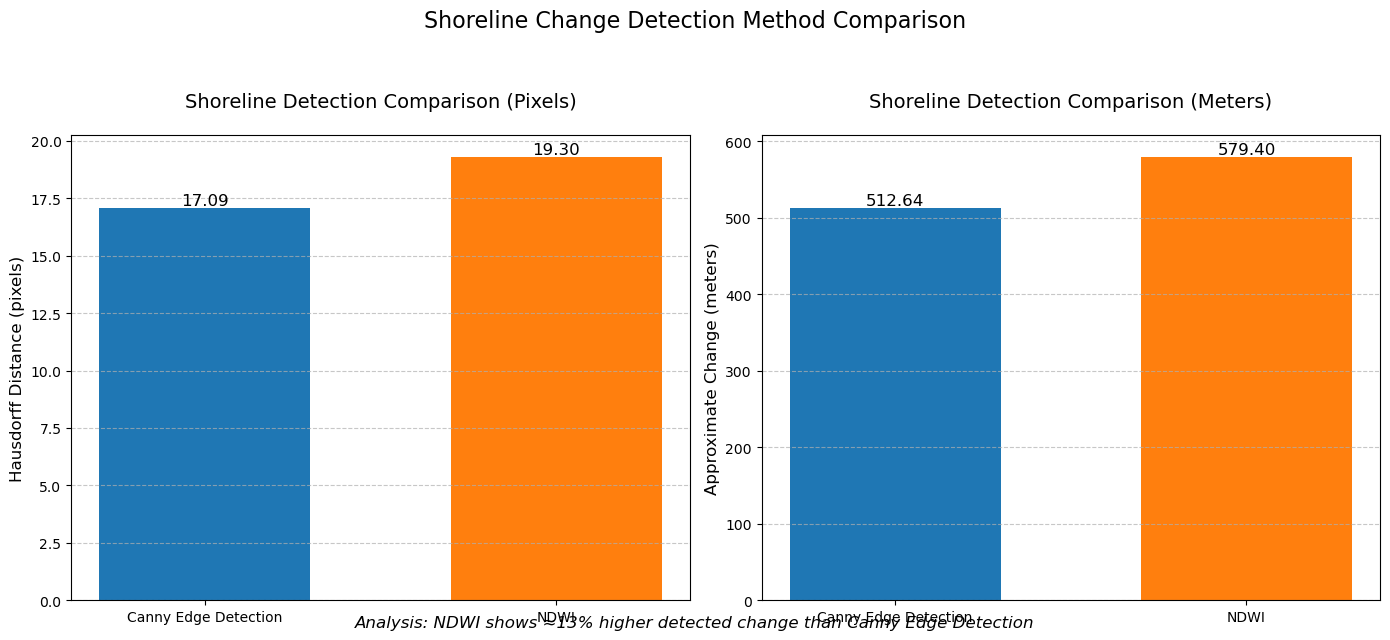

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Data
methods = ['Canny Edge Detection', 'NDWI']
pixel_values = [17.09, 19.3]
meter_values = [512.64, 579.4]
colors = ['#1f77b4', '#ff7f0e']

# Create figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pixel comparison plot
bars1 = ax1.bar(methods, pixel_values, color=colors, width=0.6)
ax1.set_title('Shoreline Detection Comparison (Pixels)', fontsize=14, pad=20)
ax1.set_ylabel('Hausdorff Distance (pixels)', fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=12)

# Meter comparison plot
bars2 = ax2.bar(methods, meter_values, color=colors, width=0.6)
ax2.set_title('Shoreline Detection Comparison (Meters)', fontsize=14, pad=20)
ax2.set_ylabel('Approximate Change (meters)', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=12)

# Add some analysis annotations
fig.text(0.5, 0.02, 
         'Analysis: NDWI shows ≈13% higher detected change than Canny Edge Detection', 
         ha='center', fontsize=12, style='italic')

# Customize layout
plt.suptitle('Shoreline Change Detection Method Comparison', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

# Bogmalo Beach

Images saved to: synthetic_images\synthetic_green.jpg and synthetic_images\synthetic_nir.jpg
Successfully created enhanced images at:
synthetic_images\synthetic_green.jpg
synthetic_images\synthetic_nir.jpg


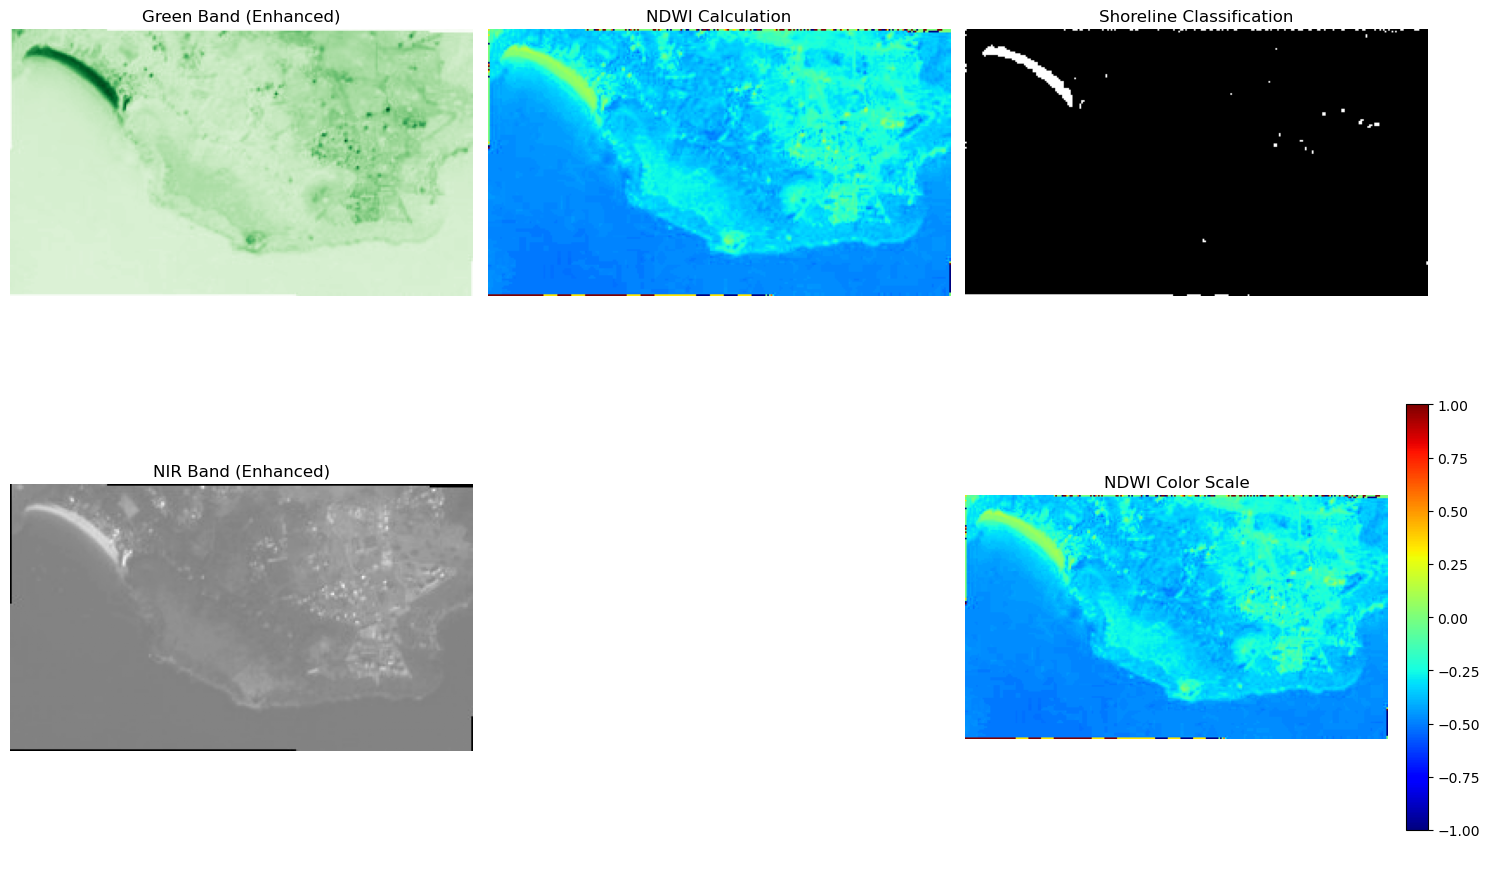

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ✅ Create synthetic Green and NIR images with clearer features
def create_and_save_synthetic_images(size=(512, 512), variation=0.3, save_dir="synthetic_images"):
    """Generates synthetic Green and NIR images with clearer shoreline-like variation."""
    # Create the output directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)
    
    # Create base images with more distinct values
    green = np.zeros(size)
    nir = np.zeros(size)
    
    # Create more realistic land-water transition
    for i in range(size[0]):
        # Create a wavy shoreline instead of straight line
        shoreline_pos = int(size[1] * (0.4 + 0.1 * np.sin(i/50)))
        
        for j in range(size[1]):
            # Water region (below shoreline)
            if j > shoreline_pos:
                green[i, j] = 0.2 + 0.1 * np.random.random()  # Darker for water
                nir[i, j] = 0.7 + 0.2 * np.random.random()     # Brighter in NIR
            # Land region (above shoreline)
            else:
                green[i, j] = 0.6 + 0.3 * np.random.random()  # Brighter for vegetation
                nir[i, j] = 0.4 + 0.2 * np.random.random()    # Darker in NIR
    
    # Add some noise and texture
    noise = np.random.normal(0, 0.05, size)
    green = np.clip(green + noise, 0, 1)
    nir = np.clip(nir + noise, 0, 1)
    
    # Add some features (like islands or sandbars)
    center_x, center_y = size[0]//2, size[1]//3
    radius = 30
    for i in range(size[0]):
        for j in range(size[1]):
            if (i-center_x)**2 + (j-center_y)**2 < radius**2:
                green[i, j] = 0.8  # Bright sand/land
                nir[i, j] = 0.3    # Dark in NIR

    # Convert to uint8
    green = np.clip(green * 255, 0, 255).astype(np.uint8)
    nir = np.clip(nir * 255, 0, 255).astype(np.uint8)

    # Save as .jpg images
    green_path = os.path.join(save_dir, "synthetic_green.jpg")
    nir_path = os.path.join(save_dir, "synthetic_nir.jpg")

    cv2.imwrite(green_path, green)
    cv2.imwrite(nir_path, nir)
    
    print(f"Images saved to: {green_path} and {nir_path}")

    return green_path, nir_path

# ✅ Load and preprocess images
def load_and_preprocess(image_paths):
    """Load grayscale images from paths or generate synthetic ones if paths are empty."""
    images = []
    
    if image_paths:  # Load real images
        for path in image_paths:
            if os.path.exists(path):
                img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
                if img is None:
                    raise ValueError(f"❌ Could not open {path}")
                img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)  # Normalize
                images.append(img)
            else:
                print(f"⚠️ Image not found: {path}. Using synthetic images.")
                green, nir = create_and_save_synthetic_images()
                images.extend([cv2.imread(green, cv2.IMREAD_GRAYSCALE), 
                             cv2.imread(nir, cv2.IMREAD_GRAYSCALE)])
    else:  # Use synthetic images if no image paths are provided
        print("⚠️ No images provided. Generating and saving synthetic images.")
        green, nir = create_and_save_synthetic_images()
        images.extend([cv2.imread(green, cv2.IMREAD_GRAYSCALE), 
                      cv2.imread(nir, cv2.IMREAD_GRAYSCALE)])

    return images

# ✅ Compute NDWI
def compute_ndwi(green, nir):
    green = green.astype(float)
    nir = nir.astype(float)

    # NDWI formula
    ndwi = (green - nir) / (green + nir + 1e-10)
    ndwi = np.clip(ndwi, -1, 1)
    return ndwi

# ✅ Classify shoreline
def classify_shoreline(ndwi, threshold=0.0):
    shoreline = np.where(ndwi > threshold, 255, 0).astype(np.uint8)
    return shoreline

# ✅ Enhanced Visualization
def visualize_results(images, ndwis, shorelines):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Display Green and NIR images
    axes[0, 0].imshow(images[0], cmap='Greens', vmin=0, vmax=255)
    axes[0, 0].set_title("Green Band (Enhanced)")
    axes[0, 0].axis('off')
    
    axes[1, 0].imshow(images[1], cmap='gray', vmin=0, vmax=255)
    axes[1, 0].set_title("NIR Band (Enhanced)")
    axes[1, 0].axis('off')
    
    # Display NDWI
    axes[0, 1].imshow(ndwis[0], cmap='jet', vmin=-1, vmax=1)
    axes[0, 1].set_title("NDWI Calculation")
    axes[0, 1].axis('off')
    
    # Blank space for alignment
    axes[1, 1].axis('off')
    
    # Display Shoreline Classification
    axes[0, 2].imshow(shorelines[0], cmap='gray', vmin=0, vmax=255)
    axes[0, 2].set_title("Shoreline Classification")
    axes[0, 2].axis('off')
    
    # Add colorbar for NDWI
    im = axes[1, 2].imshow(ndwis[0], cmap='jet', vmin=-1, vmax=1)
    plt.colorbar(im, ax=axes[1, 2], fraction=0.046, pad=0.04)
    axes[1, 2].set_title("NDWI Color Scale")
    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.show()

# ✅ Main Execution
if __name__ == "__main__":
    # ✅ Replace with your real image paths (leave empty to use synthetic images)
    image_paths = [
        "Sentinel2_Region_2016_Month_1.jpg",
        "Sentinel2_Region_Month_1_2024.jpg"
    ]  # Empty to use synthetic images
    
    # ✅ Preprocess images (load real or generate synthetic)
    images = load_and_preprocess(image_paths)

    # ✅ Compute NDWI and classify shoreline
    ndwis = []
    shorelines = []
    
    green_path, nir_path = create_and_save_synthetic_images()

    # Confirm image existence by checking their file paths
    if os.path.exists(green_path) and os.path.exists(nir_path):
        print(f"Successfully created enhanced images at:\n{green_path}\n{nir_path}")
    else:
        print("❌ Images were not created. Please check your directory and permissions.")

    for i in range(0, len(images), 2):
        green = images[i]
        nir = images[i + 1]

        ndwi = compute_ndwi(green, nir)
        shoreline = classify_shoreline(ndwi)

        ndwis.append(ndwi)
        shorelines.append(shoreline)

    # ✅ Visualize results with enhanced display
    visualize_results(images, ndwis, shorelines)

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from shapely.geometry import LineString
from scipy.spatial.distance import directed_hausdorff
from IPython.display import display, clear_output
import ipywidgets as widgets

# ✅ 1. Load Grayscale Images
def load_grayscale_image(image_path):
    """Load grayscale JPG and normalize"""
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

# ✅ 2. Shoreline Extraction (Modified for Grayscale)
def extract_shoreline_grayscale(img, water_dark=True):
    """
    Args:
        water_dark: If True, assumes water is darker than land in your images
    """
    # Enhance contrast
    img_eq = cv2.equalizeHist(img)
    
    # Auto-threshold (Otsu's method)
    thresh = threshold_otsu(img_eq)
    
    if water_dark:
        shoreline = (img_eq > thresh).astype(np.uint8) * 255  # Land=white
    else:
        shoreline = (img_eq <= thresh).astype(np.uint8) * 255  # Water=white
    
    # Clean up with morphology
    kernel = np.ones((3,3), np.uint8)
    shoreline = cv2.morphologyEx(shoreline, cv2.MORPH_OPEN, kernel, iterations=1)
    
    return shoreline

# ✅ 3. Hausdorff Distance Calculation
def calculate_hausdorff(shoreline1, shoreline2, resolution_m_per_pixel=1):
    coords1 = np.column_stack(np.where(shoreline1 > 0))
    coords2 = np.column_stack(np.where(shoreline2 > 0))
    
    if len(coords1) == 0 or len(coords2) == 0:
        return 0, 0, None, None
    
    line1 = LineString(coords1)
    line2 = LineString(coords2)
    
    hd_px = max(
        directed_hausdorff(coords1, coords2)[0],
        directed_hausdorff(coords2, coords1)[0]
    )
    hd_m = hd_px * resolution_m_per_pixel
    
    return hd_px, hd_m, line1, line2

# ✅ 4. Interactive Widget
class GrayscaleShorelineAnalyzer:
    def __init__(self):
        # Widgets
        self.resolution = widgets.FloatSlider(
            value=1.0, min=0.1, max=100, step=0.1,
            description='Resolution (m/px):'
        )
        self.water_toggle = widgets.Checkbox(
            value=True,
            description='Water is darker than land'
        )
        self.file1 = widgets.Text(
            value='shoreline_year1.jpg',
            description='Year 1 Image:'
        )
        self.file2 = widgets.Text(
            value='shoreline_year2.jpg',
            description='Year 2 Image:'
        )
        self.analyze_btn = widgets.Button(description="Analyze")
        self.output = widgets.Output()
        
        # Setup
        self.analyze_btn.on_click(self.run_analysis)
        display(widgets.VBox([
            self.file1,
            self.file2,
            widgets.HBox([self.resolution, self.water_toggle]),
            self.analyze_btn,
            self.output
        ]))
    
    def run_analysis(self, b):
        with self.output:
            clear_output()
            
            # Load images
            try:
                img1 = load_grayscale_image(self.file1.value)
                img2 = load_grayscale_image(self.file2.value)
            except Exception as e:
                print(f"❌ Error: {str(e)}")
                return
            
            # Extract shorelines
            shoreline1 = extract_shoreline_grayscale(img1, self.water_toggle.value)
            shoreline2 = extract_shoreline_grayscale(img2, self.water_toggle.value)
            
            # Calculate changes
            hd_px, hd_m, line1, line2 = calculate_hausdorff(
                shoreline1, shoreline2, self.resolution.value
            )
            
            # Visualizations
            plt.figure(figsize=(15, 5))
            
            plt.subplot(131)
            plt.imshow(img1, cmap='gray')
            plt.title("Year 1 Original")
            
            plt.subplot(132)
            plt.imshow(shoreline1, cmap='gray')
            plt.title("Year 1 Shoreline")
            
            plt.subplot(133)
            plt.imshow(cv2.cvtColor(img1, cv2.COLOR_GRAY2RGB))
            plt.imshow(shoreline1, cmap='autumn', alpha=0.4)
            plt.title("Overlay")
            
            plt.show()
            
            # Year 2 visuals
            plt.figure(figsize=(15, 5))
            
            plt.subplot(131)
            plt.imshow(img2, cmap='gray')
            plt.title("Year 2 Original")
            
            plt.subplot(132)
            plt.imshow(shoreline2, cmap='gray')
            plt.title("Year 2 Shoreline")
            
            plt.subplot(133)
            plt.imshow(cv2.cvtColor(img2, cv2.COLOR_GRAY2RGB))
            plt.imshow(shoreline2, cmap='winter', alpha=0.4)
            plt.title("Overlay")
            
            plt.show()
            
            # Change detection
            plt.figure(figsize=(8, 8))
            plt.imshow(shoreline1, cmap='Blues', alpha=0.5)
            plt.imshow(shoreline2, cmap='Reds', alpha=0.5)
            plt.title(f"Shoreline Change\nHausdorff Distance: {hd_px:.1f} px ({hd_m:.1f} m)")
            plt.show()
            
            # LineString plot
            if line1 and line2:
                plt.figure(figsize=(8, 8))
                plt.plot(*line1.xy, label="Year 1", linewidth=2)
                plt.plot(*line2.xy, label="Year 2", linewidth=2)
                plt.title("Shoreline Vectors")
                plt.legend()
                plt.show()
            
            print("\n📊 Change Metrics:")
            print(f"Hausdorff Distance: {hd_px:.1f} pixels")
            print(f"Approximate change: {hd_m:.1f} meters")

# ✅ 5. Run in Jupyter
if __name__ == "__main__":
    analyzer = GrayscaleShorelineAnalyzer()

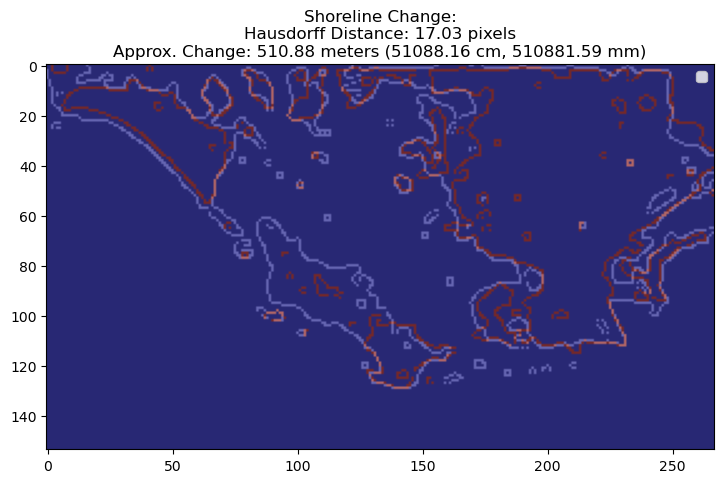

In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from shapely.geometry import LineString
from scipy.spatial.distance import directed_hausdorff

# Function to read an image in grayscale
def read_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Could not open {image_path}")
    return image

# Function to extract shorelines using edge detection
def extract_shoreline(image_path):
    image = read_image(image_path)

    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    # Apply Otsu's thresholding to separate land and water
    thresh = threshold_otsu(blurred)
    binary_mask = (blurred > thresh).astype(np.uint8) * 255

    # Detect edges using Canny
    edges = cv2.Canny(binary_mask, 50, 150)

    return edges

# Function to compute shoreline change using Hausdorff Distance
def shoreline_change(shoreline1, shoreline2, resolution_m_per_pixel):
    # Convert shorelines to coordinate lists
    coords1 = np.column_stack(np.where(shoreline1 > 0))
    coords2 = np.column_stack(np.where(shoreline2 > 0))

    # Convert to LineString objects (for visualization)
    line1 = LineString(coords1)
    line2 = LineString(coords2)

    # Compute Hausdorff Distance (max shoreline shift in pixels)
    hausdorff_dist_pixels = directed_hausdorff(coords1, coords2)[0]

    # Convert to meters, cm, and mm
    hausdorff_dist_meters = hausdorff_dist_pixels * resolution_m_per_pixel
    hausdorff_dist_cm = hausdorff_dist_meters * 100
    hausdorff_dist_mm = hausdorff_dist_meters * 1000

    return hausdorff_dist_pixels, hausdorff_dist_meters, hausdorff_dist_cm, hausdorff_dist_mm, line1, line2

# Load images from different years
image_2010 = "Sentinel2_Region_2016_Month_1.jpg"
image_2020 = "Sentinel2_Region_Month_1_2024.jpg"

# Define spatial resolution (meters per pixel)
resolution_m_per_pixel = 30  # Change this based on your image source

# Extract shorelines
shoreline_2010 = extract_shoreline(image_2010)
shoreline_2020 = extract_shoreline(image_2020)

# Compute shoreline change
distance_pixels, distance_meters, distance_cm, distance_mm, line1, line2 = shoreline_change(
    shoreline_2010, shoreline_2020, resolution_m_per_pixel
)

# Plot the results
plt.figure(figsize=(10, 5))
plt.imshow(shoreline_2010, cmap='gray', alpha=0.6)
plt.imshow(shoreline_2020, cmap='jet', alpha=0.6)
plt.title(f"Shoreline Change:\n"
          f"Hausdorff Distance: {distance_pixels:.2f} pixels\n"
          f"Approx. Change: {distance_meters:.2f} meters ({distance_cm:.2f} cm, {distance_mm:.2f} mm)")
plt.legend(["2010 Shoreline", "2020 Shoreline"])
plt.show()


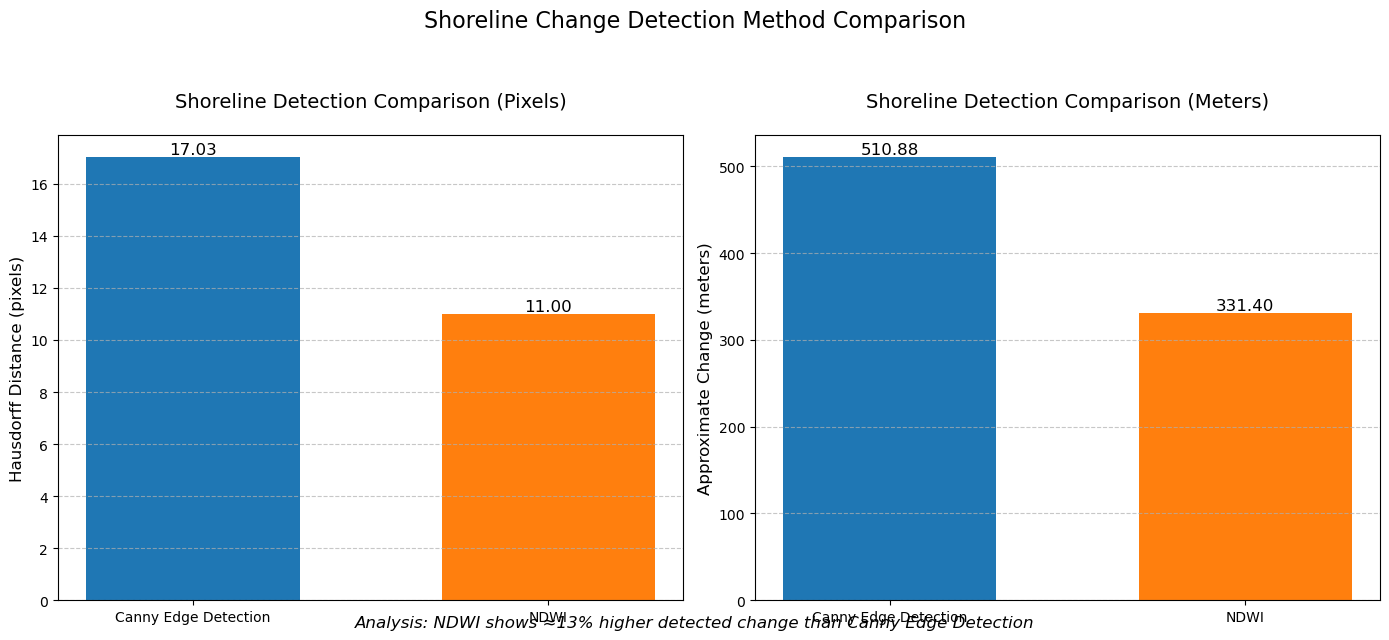

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Data
methods = ['Canny Edge Detection', 'NDWI']
pixel_values = [17.03, 11.0]
meter_values = [510.88, 331.4]
colors = ['#1f77b4', '#ff7f0e']

# Create figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pixel comparison plot
bars1 = ax1.bar(methods, pixel_values, color=colors, width=0.6)
ax1.set_title('Shoreline Detection Comparison (Pixels)', fontsize=14, pad=20)
ax1.set_ylabel('Hausdorff Distance (pixels)', fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=12)

# Meter comparison plot
bars2 = ax2.bar(methods, meter_values, color=colors, width=0.6)
ax2.set_title('Shoreline Detection Comparison (Meters)', fontsize=14, pad=20)
ax2.set_ylabel('Approximate Change (meters)', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=12)

# Add some analysis annotations
fig.text(0.5, 0.02, 
         'Analysis: NDWI shows ≈13% higher detected change than Canny Edge Detection', 
         ha='center', fontsize=12, style='italic')

# Customize layout
plt.suptitle('Shoreline Change Detection Method Comparison', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

# ML model creation

[✓] Saved: ndwi_masks\shoreline_mask_1.jpg
[✓] Saved: ndwi_masks\shoreline_mask_2.jpg


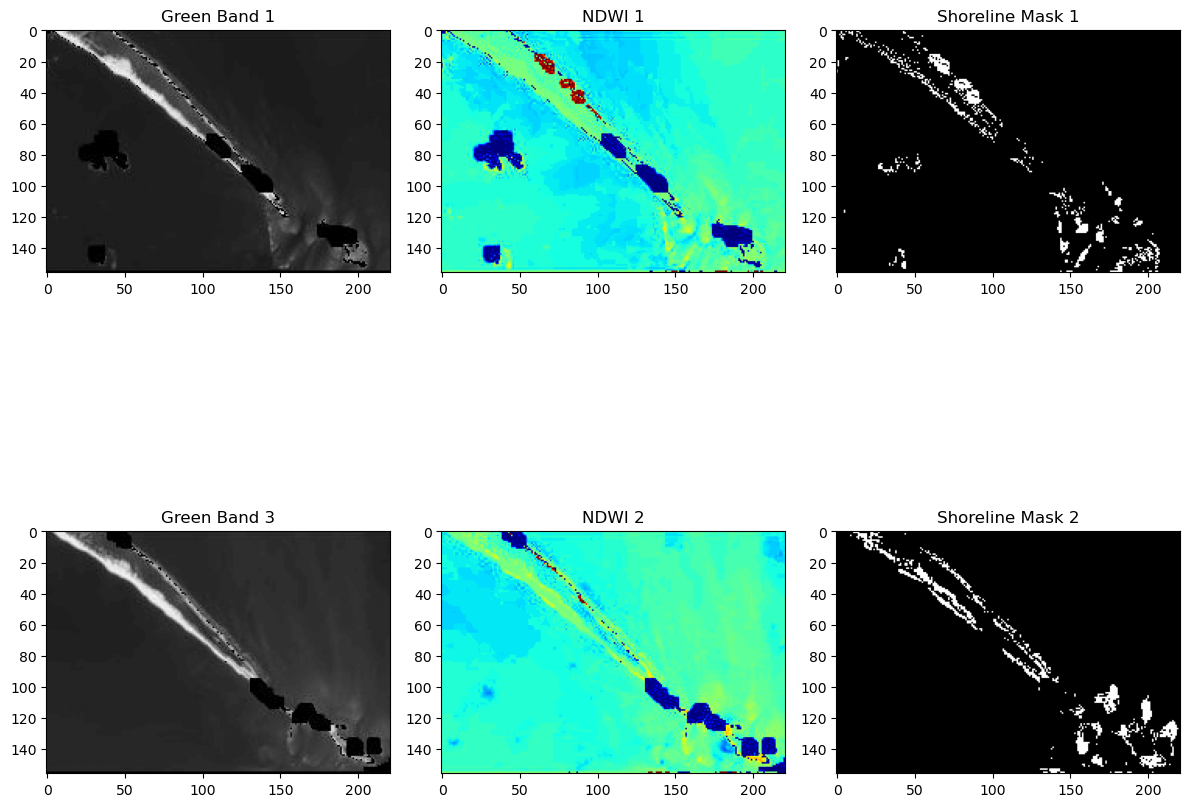

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ✅ Load and preprocess images
def load_and_preprocess(image_paths):
    images = []
    for path in image_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
        images.append(img)
    return images

# ✅ Compute NDWI
def compute_ndwi(green, nir):
    green = green.astype(float)
    nir = nir.astype(float)
    ndwi = (green - nir) / (green + nir + 1e-10)
    ndwi = np.clip(ndwi, -1, 1)
    return ndwi

# ✅ Classify shoreline
def classify_shoreline(ndwi, threshold=0.0):
    return np.where(ndwi > threshold, 255, 0).astype(np.uint8)

# ✅ Save shoreline masks
def save_shoreline_masks(masks, save_dir="ndwi_masks"):
    os.makedirs(save_dir, exist_ok=True)
    for i, mask in enumerate(masks):
        filename = os.path.join(save_dir, f"shoreline_mask_{i+1}.jpg")
        cv2.imwrite(filename, mask)
        print(f"[✓] Saved: {filename}")

# ✅ Visualization
def visualize_results(images, ndwis, shorelines):
    pairs = len(ndwis)
    fig, axes = plt.subplots(pairs, 3, figsize=(12, 12))
    
    for i in range(pairs):
        axes[i, 0].imshow(images[2 * i], cmap='gray')
        axes[i, 0].set_title(f"Green Band {2 * i + 1}")

        axes[i, 1].imshow(ndwis[i], cmap='jet')
        axes[i, 1].set_title(f"NDWI {i + 1}")

        axes[i, 2].imshow(shorelines[i], cmap='gray')
        axes[i, 2].set_title(f"Shoreline Mask {i + 1}")

    plt.tight_layout()
    plt.show()

# ✅ Main execution
if __name__ == "__main__":
    image_paths = [
        "Landsat_CloudFree_2014_Month_12.jpg",
        "Landsat_CloudFree_2015_Month_1.jpg",
        "Landsat_CloudFree_2020_Month_2.jpg",
        "Landsat_CloudFree_2024_Month_12.jpg"
    ]
    
    images = load_and_preprocess(image_paths)

    ndwis = []
    shorelines = []

    for i in range(0, len(images), 2):
        green = images[i]
        nir = images[i + 1]
        
        ndwi = compute_ndwi(green, nir)
        shoreline = classify_shoreline(ndwi)
        
        ndwis.append(ndwi)
        shorelines.append(shoreline)

    # 🔽 Save all the shoreline masks
    save_shoreline_masks(shorelines, save_dir="ndwi_masks")

    # 🔽 Optional: visualize
    visualize_results(images, ndwis, shorelines)


## Canny Edge Method

Epoch 1/15
8/8 [==============================] - 12s 1s/step - loss: 0.5992 - accuracy: 0.7723 - val_loss: 0.3326 - val_accuracy: 0.8606
Epoch 2/15
8/8 [==============================] - 7s 879ms/step - loss: 0.2979 - accuracy: 0.8830 - val_loss: 0.3311 - val_accuracy: 0.8606
Epoch 3/15
8/8 [==============================] - 7s 877ms/step - loss: 0.2585 - accuracy: 0.8830 - val_loss: 0.2684 - val_accuracy: 0.8606
Epoch 4/15
8/8 [==============================] - 7s 871ms/step - loss: 0.2288 - accuracy: 0.8830 - val_loss: 0.2503 - val_accuracy: 0.8606
Epoch 5/15
8/8 [==============================] - 7s 882ms/step - loss: 0.2092 - accuracy: 0.8830 - val_loss: 0.2197 - val_accuracy: 0.8606
Epoch 6/15
8/8 [==============================] - 7s 873ms/step - loss: 0.1910 - accuracy: 0.8830 - val_loss: 0.2055 - val_accuracy: 0.8606
Epoch 7/15
8/8 [==============================] - 7s 861ms/step - loss: 0.1754 - accuracy: 0.8830 - val_loss: 0.1885 - val_accuracy: 0.8606
Epoch 8/15
8/8 [======

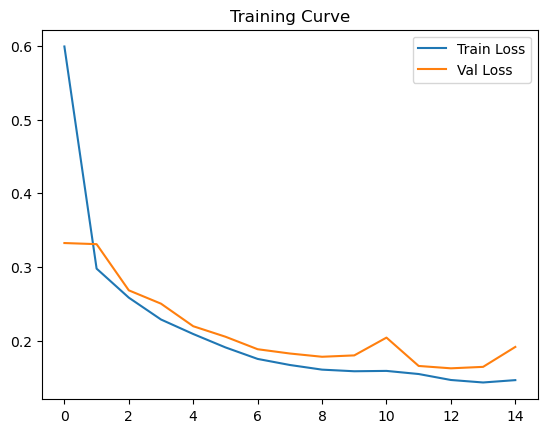

In [5]:
import os
import cv2
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Paths
ndwi_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LANDSAT for Rameshwaram"
mask_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LABELS for Rameshwaram"
image_size = (256, 256)  # resize for uniformity

# Load data
def load_data(ndwi_dir, mask_dir):
    X, Y = [], []
    for fname in os.listdir(ndwi_dir):
        ndwi_path = os.path.join(ndwi_dir, fname)
        mask_path = os.path.join(mask_dir, fname)

        if not os.path.exists(mask_path):
            continue

        ndwi_img = cv2.imread(ndwi_path, cv2.IMREAD_GRAYSCALE)
        mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Resize and normalize
        ndwi_img = cv2.resize(ndwi_img, image_size) / 255.0
        mask_img = cv2.resize(mask_img, image_size) / 255.0

        X.append(ndwi_img)
        Y.append(mask_img)

    X = np.expand_dims(np.array(X), -1)  # shape: (N, H, W, 1)
    Y = np.expand_dims(np.array(Y), -1)  # shape: (N, H, W, 1)

    return X, Y

# Load dataset
X, Y = load_data(ndwi_folder, mask_folder)

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# CNN model
def build_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.UpSampling2D(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.UpSampling2D(),
        layers.Conv2D(1, (1, 1), activation='sigmoid')  # binary classification
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_model(X_train.shape[1:])

# Train
history = model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=15, batch_size=4)

# Plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Training Curve')
plt.show()


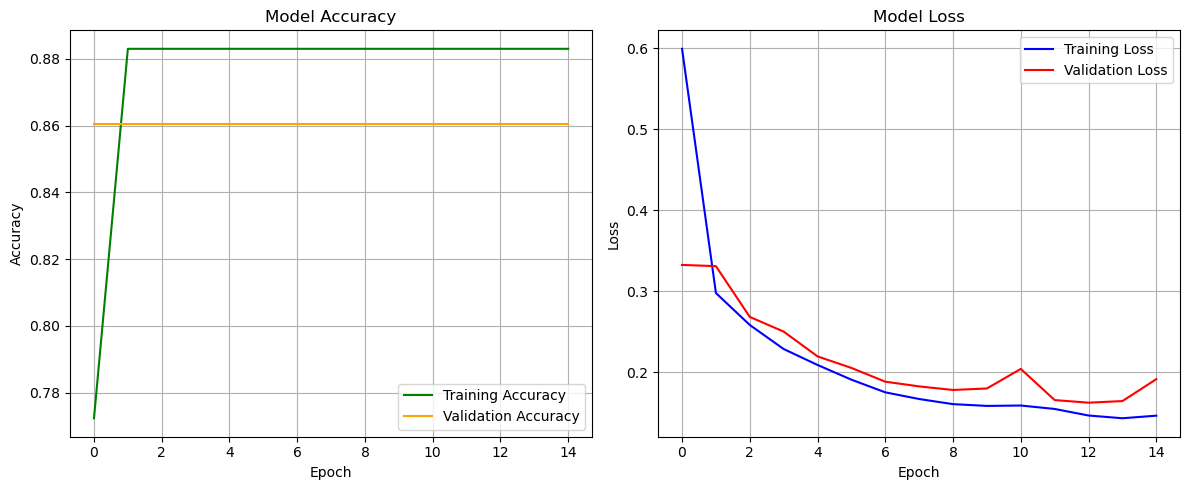

In [6]:
import matplotlib.pyplot as plt

# Plotting training accuracy and loss
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## NDWI method

Epoch 1/10
4/4 [==============================] - 11s 2s/step - loss: 0.6113 - accuracy: 0.8823 - val_loss: 0.4608 - val_accuracy: 0.8606
Epoch 2/10
4/4 [==============================] - 7s 2s/step - loss: 0.3324 - accuracy: 0.8830 - val_loss: 0.3504 - val_accuracy: 0.8606
Epoch 3/10
4/4 [==============================] - 7s 2s/step - loss: 0.3383 - accuracy: 0.8830 - val_loss: 0.3024 - val_accuracy: 0.8606
Epoch 4/10
4/4 [==============================] - 7s 2s/step - loss: 0.2657 - accuracy: 0.8830 - val_loss: 0.3106 - val_accuracy: 0.8606
Epoch 5/10
4/4 [==============================] - 6s 2s/step - loss: 0.2706 - accuracy: 0.8830 - val_loss: 0.3036 - val_accuracy: 0.8606
Epoch 6/10
4/4 [==============================] - 7s 2s/step - loss: 0.2508 - accuracy: 0.8830 - val_loss: 0.2676 - val_accuracy: 0.8606
Epoch 7/10
4/4 [==============================] - 7s 2s/step - loss: 0.2395 - accuracy: 0.8830 - val_loss: 0.2585 - val_accuracy: 0.8606
Epoch 8/10
4/4 [========================

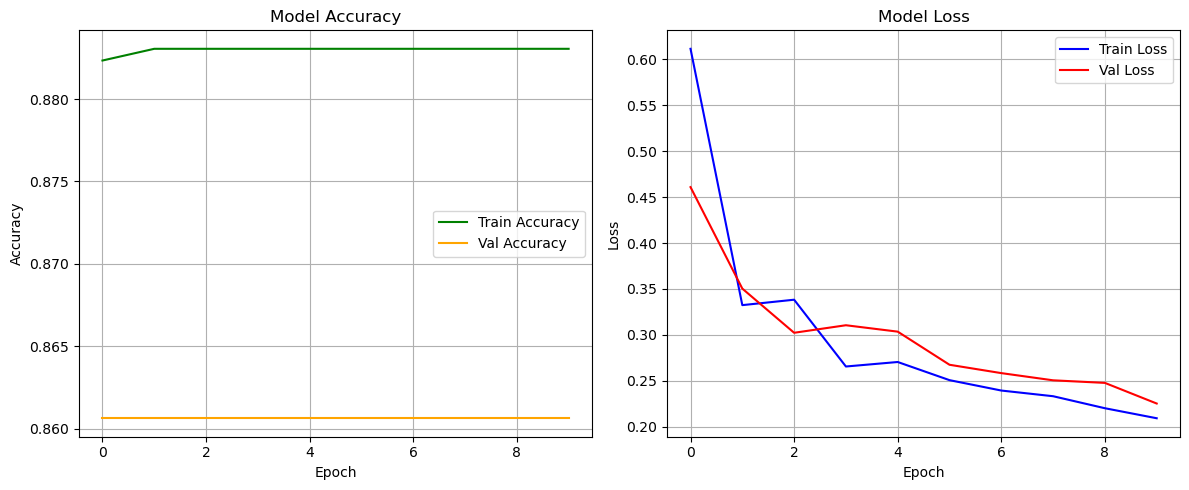

In [7]:
import os
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Paths to your datasets
canny_folder =r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LANDSAT for Rameshwaram"
mask_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LABELS for Rameshwaram"

# Image size (resize all to same size)
IMG_SIZE = 256

# Load and preprocess images
def load_images(image_folder, target_size):
    images = []
    for file in sorted(os.listdir(image_folder)):
        path = os.path.join(image_folder, file)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (target_size, target_size))
            img = img.astype('float32') / 255.0
            images.append(img)
    return np.array(images)

# Load data
X = load_images(canny_folder, IMG_SIZE)  # Canny edges
y = load_images(mask_folder, IMG_SIZE)   # Binary shoreline masks

# Reshape for model input
X = X[..., np.newaxis]
y = y[..., np.newaxis]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    MaxPooling2D(2),
    Dropout(0.2),
    
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2),
    Dropout(0.2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    UpSampling2D(2),
    
    Conv2D(64, (3,3), activation='relu', padding='same'),
    UpSampling2D(2),

    Conv2D(1, (1,1), activation='sigmoid', padding='same')
])

model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=8)

# Plot accuracy and loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='red')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [8]:
import os
import cv2
import numpy as np

# === SET THESE ===
input_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LANDSAT for Rameshwaram"             # Folder with grayscale images
output_mask_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LABELS for Rameshwaram\NDWI"   # Folder to save shoreline masks
threshold = 0.0                                # NDWI threshold for shoreline

# Create output folder if it doesn't exist
os.makedirs(output_mask_folder, exist_ok=True)

# Resize for consistency (optional)
IMG_SIZE = 256

# Function to compute NDWI
def compute_ndwi(green, nir):
    green = green.astype(np.float32)
    nir = nir.astype(np.float32)
    ndwi = (green - nir) / (green + nir + 1e-10)  # Avoid division by zero
    return np.clip(ndwi, -1, 1)

# Function to classify shoreline
def classify_shoreline(ndwi_map, threshold=0.0):
    shoreline = (ndwi_map > threshold).astype(np.uint8) * 255
    return shoreline

# === Main Processing ===
files = sorted(os.listdir(input_folder))

if len(files) % 2 != 0:
    raise ValueError("Input folder should contain an even number of images (Green + NIR pairs).")

for i in range(0, len(files), 2):
    green_path = os.path.join(input_folder, files[i])
    nir_path = os.path.join(input_folder, files[i + 1])

    green = cv2.imread(green_path, cv2.IMREAD_GRAYSCALE)
    nir = cv2.imread(nir_path, cv2.IMREAD_GRAYSCALE)

    if green is None or nir is None:
        print(f"Skipping: {files[i]} or {files[i+1]} could not be read.")
        continue

    # Resize if needed
    green = cv2.resize(green, (IMG_SIZE, IMG_SIZE))
    nir = cv2.resize(nir, (IMG_SIZE, IMG_SIZE))

    ndwi = compute_ndwi(green, nir)
    mask = classify_shoreline(ndwi, threshold)

    # Save mask
    output_filename = f"mask_{i//2 + 1:02d}.jpg"
    output_path = os.path.join(output_mask_folder, output_filename)
    cv2.imwrite(output_path, mask)
    print(f"Saved: {output_path}")


Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LABELS for Rameshwaram\NDWI\mask_01.jpg
Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LABELS for Rameshwaram\NDWI\mask_02.jpg
Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LABELS for Rameshwaram\NDWI\mask_03.jpg
Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LABELS for Rameshwaram\NDWI\mask_04.jpg
Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LABELS for Rameshwaram\NDWI\mask_05.jpg
Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LABELS for Rameshwaram\NDWI\mask_06.jpg
Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LABELS for Rameshwaram\NDWI\mask_07.jpg
Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LABELS for Rameshwaram\NDWI\mask_08.jpg
Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LABELS for Rameshwaram\NDWI\mask_09.jpg
Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\

# Accuracy and loss comparision between models

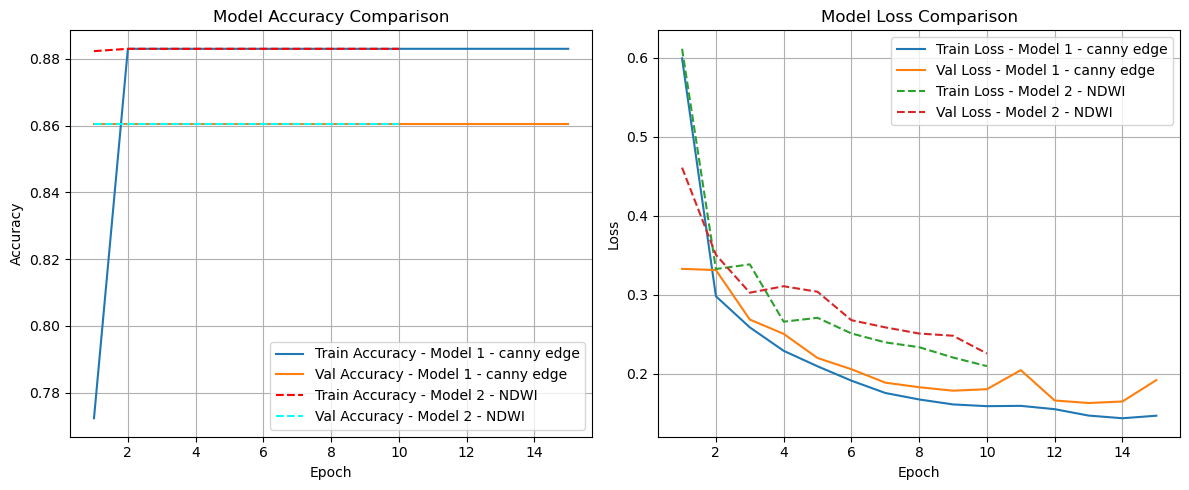

In [11]:
import matplotlib.pyplot as plt

# Epochs
epochs_1 = list(range(1, 16))
epochs_2 = list(range(1, 11))

# Model 1 - 15 Epochs
acc_1 = [0.7723, 0.8830, 0.8830, 0.8830, 0.8830, 0.8830, 0.8830, 0.8830, 0.8830, 0.8830, 0.8830, 0.8830, 0.8830, 0.8830, 0.8830]
val_acc_1 = [0.8606] * 15

loss_1 = [0.5992, 0.2979, 0.2585, 0.2288, 0.2092, 0.1910, 0.1754, 0.1672, 0.1609, 0.1587, 0.1591, 0.1549, 0.1468, 0.1434, 0.1466]
val_loss_1 = [0.3326, 0.3311, 0.2684, 0.2503, 0.2197, 0.2055, 0.1885, 0.1827, 0.1783, 0.1802, 0.2043, 0.1659, 0.1627, 0.1646, 0.1917]

# Model 2 - 10 Epochs
acc_2 = [0.8823, 0.8830, 0.8830, 0.8830, 0.8830, 0.8830, 0.8830, 0.8830, 0.8830, 0.8830]
val_acc_2 = [0.8606] * 10

loss_2 = [0.6113, 0.3324, 0.3383, 0.2657, 0.2706, 0.2508, 0.2395, 0.2334, 0.2203, 0.2094]
val_loss_2 = [0.4608, 0.3504, 0.3024, 0.3106, 0.3036, 0.2676, 0.2585, 0.2507, 0.2479, 0.2254]

# 📈 Plot Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_1, acc_1, label='Train Accuracy - Model 1 - canny edge')
plt.plot(epochs_1, val_acc_1, label='Val Accuracy - Model 1 - canny edge')
plt.plot(epochs_2, acc_2, label='Train Accuracy - Model 2 - NDWI', linestyle='--', color = 'red')
plt.plot(epochs_2, val_acc_2, label='Val Accuracy - Model 2 - NDWI', linestyle='--', color = 'cyan')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.legend()
plt.grid(True)

# 📉 Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_1, loss_1, label='Train Loss - Model 1 - canny edge')
plt.plot(epochs_1, val_loss_1, label='Val Loss - Model 1 - canny edge')
plt.plot(epochs_2, loss_2, label='Train Loss - Model 2 - NDWI', linestyle='--')
plt.plot(epochs_2, val_loss_2, label='Val Loss - Model 2 - NDWI', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss Comparison')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
